## Exploring plasticity - both facilitation and depression

In [10]:
%matplotlib inline

import numpy as np
from numpy import random
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import itertools
import seaborn as sns
import os
print(os.getcwd())
import sys
Path = os.getcwd()
sys.path.append(Path)
from plasticity_network import *
from utilities1 import *

/home/tonje/master/TIS

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:22

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [ ]:


def test_single_synapse(plasticity=False, U=0.5, tau_rec=800.0, tau_fac=0.0):
    """Test the effect of short-term plasticity on a single synapse.
    The test explores the effect of short-term plasticity on a single synapse
    by using a predefined set of spike times to stimulate a postsynaptic neuron."""
    
    nest.ResetKernel()
    nest.SetKernelStatus({
        "resolution": 0.1,
        "rng_seed": 42
    })

    tau_syn_ex = 2.0
    delay = 1.0
    weight = 100.0
    U = 0.5

    # Five spikes at 20 Hz, followed by one spike after recovery
    spike_times = np.array([
        100.0,
        150.0,
        200.0,
        250.0,
        300.0,
        1300.0
    ])

    presynaptic_input = nest.Create(
        "spike_generator",
        params={"spike_times": spike_times}
    )

    presynaptic_neuron = nest.Create("parrot_neuron")

    postsynaptic_neuron = nest.Create(
        "iaf_psc_alpha",
        params={
            "C_m": 100.0,
            "tau_m": 10.0,
            "tau_syn_ex": tau_syn_ex,
            "E_L": -60.0,
            "V_m": -60.0,
            "V_reset": -60.0,

            # High threshold prevents the neuron from firing
            "V_th": 1000.0
        }
    )

    nest.Connect(presynaptic_input, presynaptic_neuron,
                syn_spec={"synapse_model": "static_synapse",
                            "delay": 0.1
    }
)

    multimeter = nest.Create(
        "multimeter",
        params={
            "interval": 0.1,
            "record_from": ["I_syn_ex", "V_m"]
        }
    )

    nest.Connect(multimeter, postsynaptic_neuron)

    if plasticity:
        nest.Connect(
            presynaptic_neuron,
            postsynaptic_neuron,
            syn_spec={
                "synapse_model": "tsodyks_synapse",

                # Divide by U so that the first EPSC has
                # approximately the same amplitude as the static EPSC
                "weight": weight / U,

                "delay": delay,
                "U": U, # increase in u with eaxh spike
                "u": 0.0,
                "x": 1.0,
                "y": 0.0,
                "tau_rec": tau_rec, # how fast vesicles are restored 
                "tau_fac": tau_fac, # how fast vesicle release falls after spike
                "tau_psc": tau_syn_ex # rise time of the postsynaptic current
            }
        )

    else:
        nest.Connect(
            presynaptic_input,
            postsynaptic_neuron,
            syn_spec={
                "synapse_model": "static_synapse",
                "weight": weight,
                "delay": delay
            }
        )

    nest.Simulate(1400.0)

    events = multimeter.get("events")

    return {
        "times": np.asarray(events["times"]),
        "I_syn_ex": np.asarray(events["I_syn_ex"]),
        "V_m": np.asarray(events["V_m"]),
        "spike_times": spike_times,
        "delay": delay
    }

In [ ]:
static_results = test_single_synapse(
    plasticity=False
)

depressing_results = test_single_synapse(
    plasticity=True,
    U=0.5,
    tau_rec=800.0,
    tau_fac=0.0
)

facilitating_results = test_single_synapse(
    plasticity=True,
    U=0.03,
    tau_rec=50.0,
    tau_fac=530.0
)


Aug 24 11:44:29 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.

Aug 24 11:44:29 NodeManager::prepare_nodes [Info]: 
    Preparing 4 nodes for simulation.

Aug 24 11:44:29 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 4
    Simulation time (ms): 1400
    Number of OpenMP threads: 1
    Number of MPI processes: 1

Aug 24 11:44:29 SimulationManager::run [Info]: 
    Simulation finished.

Aug 24 11:44:29 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.

Aug 24 11:44:29 NodeManager::prepare_nodes [Info]: 
    Preparing 4 nodes for simulation.

Aug 24 11:44:29 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 4
    Simulation time (ms): 1400
    Number of OpenMP threads: 1
    Number of MPI processes: 1

Aug 24 11:44:29 SimulationManager::run [Info]: 
    Simulation finished.

Aug 24 11:44:29 SimulationManager::set_status [Info]: 
    Temporal resolution change

### Short term depression

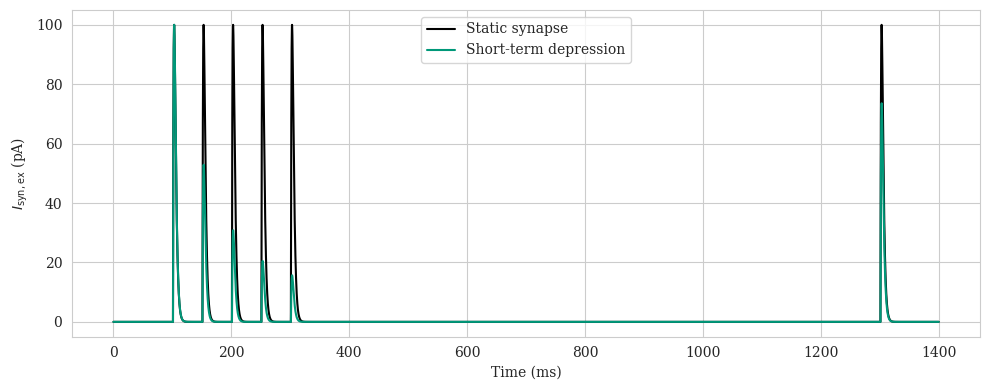

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    static_results["times"],
    static_results["I_syn_ex"],
    label="Static synapse",
    color="black"
)

plt.plot(
    depressing_results["times"],
    depressing_results["I_syn_ex"],
    label="Short-term depression",
    color="#009879"
)

plt.xlabel("Time (ms)")
plt.ylabel(r"$I_{\mathrm{syn,ex}}$ (pA)")
plt.legend()
plt.tight_layout()
plt.show()

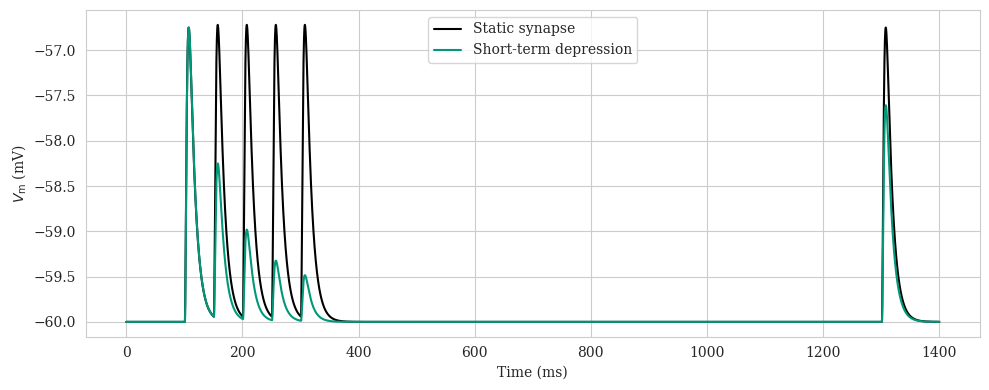

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    static_results["times"],
    static_results["V_m"],
    label="Static synapse",
    color="black"
)

plt.plot(
    depressing_results["times"],
    depressing_results["V_m"],
    label="Short-term depression",
    color="#009879"
)

plt.xlabel("Time (ms)")
plt.ylabel(r"$V_{\mathrm{m}}$ (mV)")
plt.legend()
plt.tight_layout()
plt.show()

### Short term facilitation

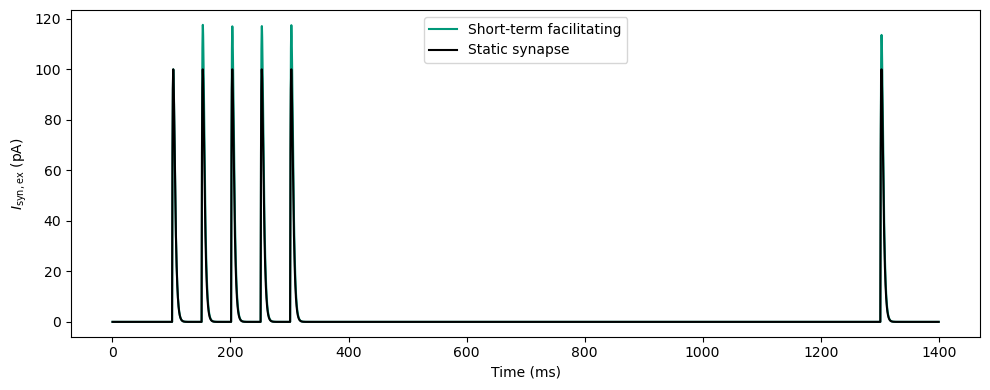

In [8]:
plt.figure(figsize=(10, 4))

plt.plot(
    facilitating_results["times"],
    facilitating_results["I_syn_ex"],
    label="Short-term facilitating",
    color="#009879"
)

plt.plot(
    static_results["times"],
    static_results["I_syn_ex"],
    label="Static synapse",
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel(r"$I_{\mathrm{syn,ex}}$ (pA)")
plt.legend()
plt.tight_layout()
plt.show()

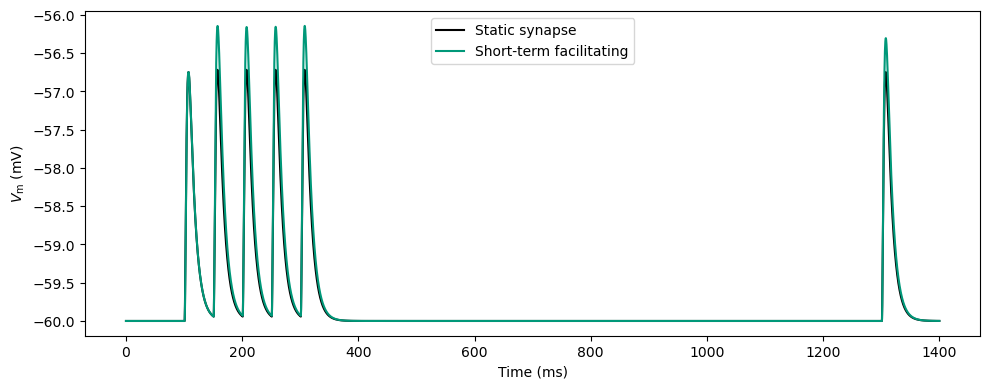

In [9]:
plt.figure(figsize=(10, 4))

plt.plot(
    static_results["times"],
    static_results["V_m"],
    label="Static synapse",
    color="black"
)

plt.plot(
    facilitating_results["times"],
    facilitating_results["V_m"],
    label="Short-term facilitating",
    color="#009879"
)

plt.xlabel("Time (ms)")
plt.ylabel(r"$V_{\mathrm{m}}$ (mV)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
def plot_results(sim_time=5000, noisy=False, delay_mean=1.0, delay_sd=0.25, weight=1, zoom_out=False,
                 second_sine=False,xLim=1, y_min=1e-12,a_values=[100], SD_values=[250],
                 f_values=[10], beat=20, E_m=-60, V_th=-50, bin_size=0.25, tau_m=10, psd_segments=16,
                 seed=np.random.randint(0,1e+6), resolution=0.25, num_A=1000, common_noise=False,
                 log=True, harmonics=1, harmonics_beat=0, V_thresh=-50,tau_syn_ex=2,
                 measure_from_A=False, seed_check=False, neuron_type="iaf_psc_alpha", 
                autocorr_validation=False, demean=False, welch=False,
                normalize=False, Cm=100, letter_idx=0, tau_fac=0.0, tau_rec=800.0, U=0.5):
    """This function plots:
    - Membrane potential as a function of time for a given length within simulation time (xLim)
    - The PSD of the spike train
    - The PSD of the membrane potential
        noisy: whether to include noise or not (True/False)
        sim_time: duration of simulation (ms)
        psd_segments: number of segments in welch psd
        second_sine : whether to include second AC generator or not (True/False)
        xLim : limiting the time axis of the membrane potential (max value) (ms)
        a_values : input amplitudes (pA)
        SD_values : input noise level (standard deviation) (pA)
        f_values : input frequencies (Hz)
        beat : frequency offset (Hz)
        E_m : resting potential (mV)
        V_th : Threshold for firing action potentials (mV)
        bin_size : width of frequency (Hz)
        seed : random number (or set by user for control).
        Necessary for generation of stochastic noise,
        resolution : temporal resolution/length of time steps (ms)
        legend : Whether to put legend outside plots (True/False)
        log : Whether to use loglog-plot or not (True/False)
        y_min : min value for PSD of spike train (varies a lot)
        harmonics : number of harmonics of input frequencies indicated in PSD-plot
        harmonics_beat : number of harmonics of beat frequency indicated in PSD- plot
        measure_from_A : whether to measure from a neuron in population A instead of B (True/False)
        seed_check : whether to plot membrane potentials for two neurons in pop. A (True/False)"""

    
    ###*************************SIMULATION**************************************
    if noisy:
        param_combos = list(itertools.product(f_values,a_values, SD_values))
        
    else:
        param_combos = list(itertools.product(f_values, a_values))
    
    param_combos = np.atleast_1d(param_combos) #to allow for one single combination
    
    
    fig, axes = plt.subplots(nrows=len(param_combos), ncols=3, 
                             figsize=(18, 6*len(param_combos)))
    
    if len(param_combos) == 1:
        axes = np.array([axes])
    
    for idx, combo  in enumerate(param_combos):
        if noisy:
            f, a, sd = combo  
            results = build_network(sim_time=sim_time, noisy=noisy, second_sine=second_sine, V_thresh=V_th, neuron_type=neuron_type,
                                        f1=f, beat=beat, a=a, SD=sd, tau_m=tau_m, num_A=num_A, weight=weight,
                                        seed=seed, resolution=resolution, measure_from_A=measure_from_A, common_noise=common_noise,
                                        delay_mean=delay_mean, delay_sd=delay_sd, tau_syn_ex=tau_syn_ex, Cm=Cm, tau_fac=tau_fac, tau_rec=tau_rec, U=U) 
            
        else:
            f,a = combo
            results = build_network(sim_time=sim_time, noisy=noisy, second_sine=second_sine, V_thresh=V_th,
                                        f1=f, beat=beat, a=a, tau_m=tau_m, num_A=num_A, weight=weight, neuron_type=neuron_type,
                                        seed=seed, resolution=resolution, measure_from_A=measure_from_A, 
                                        delay_mean=delay_mean, delay_sd=delay_sd, tau_syn_ex=tau_syn_ex, Cm=Cm, tau_fac=tau_fac, tau_rec=tau_rec, U=U) 
            
            
         #********************************RESULTS AND PLOTS********************************   
        spike_times = results["spike_times"]
        Vm = results["Vm"]
        V_th = results["V_th"]
        sim_time = results["sim_time"]
        times = results["times"]
        tot_spike_rate = results["tot_spike_rate"]
        
        
        # Layout
        sns.set_style("whitegrid")
        plt.rcParams["font.family"] = "DejaVu Serif"
        
        # Membrane potential with threshold 
       
        ax_vm = axes[idx,0]
            
        time_axis = np.linspace(0,sim_time,len(Vm))
        
        for t in spike_times:
            ax_vm.vlines(x=t, ymin=V_th, ymax=V_th+5, color="black") 
            
        ax_vm.plot(times, Vm, color='#006D5B')
        ax_vm.axhline(V_th, linestyle='-', color='black', label="V_th")  # terskel-linje
        
        
        # Setting title based on configuration of simulation
        letters = "ABCDEFGHIJKLMNOPQ"
        
        if noisy:
            if second_sine:
                ax_vm.set_title(
                rf"{letters[letter_idx+idx*3]}. $V_m$ ($f_1$ = {f:.0f}Hz, $f_2$ = {f + beat :.0f}Hz, " +
                rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)",
                fontsize=14, fontweight='bold', color="#006D5B"
                )
            else:
                ax_vm.set_title(
                rf"{letters[3*idx+letter_idx]}.$V_m$ ($f$ = {f:.0f}Hz, $I_\sigma$ = {sd:.0f}pA, " +
                rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)",
                fontsize=14, fontweight='bold', color="#006D5B"
                )
        else:
            if second_sine:
                ax_vm.set_title(
                rf"{letters[3*idx+letter_idx]}. $V_m$ ($f_1$ = {f:.0f}Hz, $f_2$ = {f + beat:.0f}Hz, " +
                rf"$I_{{\mathrm{{I}}}}$ = {a:.0f}pA)",
                fontsize=14, fontweight='bold', color="#006D5B"
                )
            else:
                ax_vm.set_title(
                rf"{letters[3*idx+letter_idx]} $V_m$ ($f$ = {f:.0f}Hz, $I_{{\mathrm{{I}}}}$ = {a:.0f}pA)",
                fontsize=14, fontweight='bold', color="#006D5B")
                
                
            # removing frequencies from the title if the input amplitude is zero
        #if a == 0:
        #    title = title.replace(r"($f$ = " + f"{f:.0f}" + r"Hz, ", "(")
        #    title = title.replace(r"($f_1$ = " + f"{f:.0f}" + r"Hz, $f_2$ = " + f"{f + beat:.0f}" + r"Hz, ", "(")

            
        ax_vm.set_xlim([1000, 1000+xLim*1000])
        if np.all(Vm!=-60):
            ax_vm.set_ylim([np.min(Vm)-5,np.max(Vm)+10])
        else:
            ax_vm.set_ylim(np.min(Vm)-5, np.max(Vm)+10)
        ax_vm.set_xlabel("Time [ms]", color="#006D5B", fontsize=16)
        ax_vm.set_ylabel(r"$V_\mathrm{m}\, [\mathrm{mV}]$", color="#006D5B", fontsize=16)
        
        #chat-gpt:
        plot_layout(ax_vm)

        # PSD of spike train
        if zoom_out:
            freqs, psd_values = psd(spike_times, sim_time, bin_size=0.1, f=8000)
        else:    
            if welch:
                freqs, psd_values = psd_welch(spike_times, sim_time, bin_size, psd_segments, f, demean, normalize)
            else:
                freqs, psd_values = psd(spike_times, bin_size, sim_time, f, demean)
        
        print("siste frekvens i freq:", freqs[-1])
        freqs = freqs[10:]
        psd_values = psd_values[10:]
        arg_f = np.argmin(np.abs(freqs - f))
        
        if second_sine:
            arg_beat = np.argmin(np.abs(freqs - beat))
        else:
            arg_beat = None
        
        ax_fft = axes[idx,1]
        
        # Vertical lines indicating harmonics, colors filled in by chat GPT
        beat_colors = ["teal", "#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
        colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B", "#FF9800","#F4E91E63","#9C27B0","#673AB7", 
    "#3F51B5"] # Green colors for harmonics
        
        for i in range(1,harmonics_beat+1):
            ax_fft.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"f={i*beat}Hz")
            
        for i in range(1,harmonics+1):
            ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
            if second_sine:
                ax_fft.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"{i*(f+beat)}Hz")
            ax_fft.legend()
        
        
        ax_fft.plot(freqs, psd_values, color="#006D5B") 

        if autocorr_validation:
            if welch: 
                freqs_auto, auto_values = welch_autocorr(spike_times, bin_size, sim_time, psd_segments, f, demean, normalize)
            else:
                freqs_auto, auto_values = psd_autocorr(spike_times, bin_size, sim_time, f=f, demean=demean )
            arg_f_auto = np.argmin(np.abs(freqs_auto - f))
            keep_args = auto_values > 1e-30
            auto_values = auto_values[keep_args]
            print("len autovalues", len(auto_values))
            
            freqs_auto = freqs_auto[keep_args]
            ax_fft.plot(freqs_auto, auto_values, color="midnightblue", alpha=0.6, label="autocorr") 

        # table of important values
        if noisy:
            if second_sine == False:
                beat = 0
            if autocorr_validation:
                df, noise_avg = simulated_SNR(Vm, a, psd_values, f, freqs, 
                                          arg_f, sim_time, sd, beat, spike_times, second_sine,
                                          freqs_auto, auto_values)
            else:
                  df, noise_avg = simulated_SNR(Vm, a, psd_values, f, freqs, 
                                          arg_f, sim_time, sd, beat, spike_times, second_sine)
                      
            df["Population spike-rate"] = tot_spike_rate
            display(df)
        
        xMax = max(f,np.max(freqs))*1.1
        if log:
            ax_fft.set_xscale("log")
            ax_fft.set_yscale("log")
            # xticks and yticks
            ax_fft.xaxis.set_major_locator(LogLocator(base=10.0)) 
            ax_fft.yaxis.set_major_locator(LogLocator(base=10.0))
            
        ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
        ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
        ax_fft.set_title(f"{letters[1+letter_idx+3*idx]}. PSD of spike train", fontsize=18, fontweight='bold', color="#006D5B")
        
     

    
        # PSD of membrane potential
        freqs, fft_vm = psd_Vm(Vm, times, bin_size, f=f)
        fft_vm = np.abs(fft_vm)
        
        ax_fft_vm = axes[idx,2]
        for i in range(1,harmonics_beat+1):
            ax_fft_vm.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"{i*beat}Hz")
            
        for i in range(1,harmonics+1):
            ax_fft_vm.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
            if second_sine:
                ax_fft_vm.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"{i*(f+beat)}Hz")
            
        ax_fft_vm.legend()    

        
            
        ax_fft_vm.plot(freqs, np.abs(fft_vm), color='#006D5B') 

        if autocorr_validation:
            freqs_auto, auto_values = psd_Vm_autocorr(Vm, bin_size,  sim_time, resolution)
            keep_args = auto_values > 1e-30
            auto_values = auto_values[keep_args]
            print("len autovalues", len(auto_values))
            freqs_auto = freqs_auto[keep_args]
            ax_fft_vm.plot(freqs_auto, auto_values, color="midnightblue", alpha=0.6, label="autocorr") 
        
        if len(psd_values) > 0:
            ymin = max(3e-5, np.min(np.abs(psd_values)))
            ymax = np.max(np.abs(psd_values))*1.1
            if autocorr_validation == True:
                ymin = max(1e-7, np.min(np.abs(auto_values)))
                ymax = max(np.max(auto_values), np.max(psd_values))
        
        #ax_fft.set_ylim(ymin,ymax)
        ax_fft.set_xlim(1,2e3)
        
        plot_layout(ax_fft)
        
    

        ymin = max(y_min, np.min(np.abs(fft_vm)))
        ax_fft_vm.set_ylim(ymin,10*np.max(np.abs(fft_vm)))
        ax_fft_vm.set_xlabel("Frequency [Hz]", color="#006D5B", fontsize=16)
        ax_fft_vm.set_ylabel(r'PSD [$(\mathrm{mV})^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
        ax_fft_vm.set_title(f"{letters[2+letter_idx+3*idx]}. PSD of $V_m$", fontsize=20, fontweight='bold', color="#006D5B")
        if np.any(Vm!=-60): 
            ax_fft_vm.set_xscale("log")
            ax_fft_vm.set_yscale("log")
            ax_fft_vm.xaxis.set_major_locator(LogLocator(base=10.0))
            ax_fft_vm.yaxis.set_major_locator(LogLocator(base=10.0))
            
        plot_layout(ax_fft_vm)
        plot_isi(spike_times)
        plt.tight_layout()
        save_figure(fig, "exc_network")
    plt.show()
        
  

## Testing the plasticity model in neural network
### Short term depression


Aug 25 12:41:09 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Aug 25 12:41:09 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000115,3.641176,14.21,7.54,8.04,84.64,0.97,7.81,3.83,1.0,7.8,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_165.png


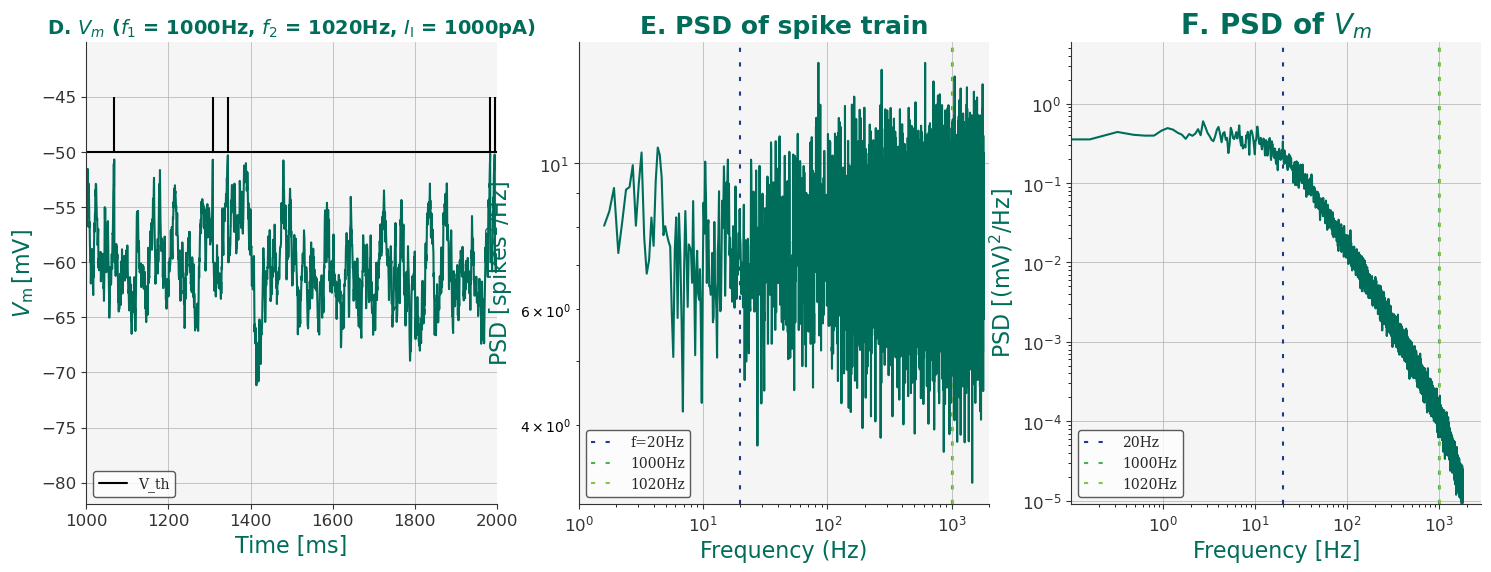

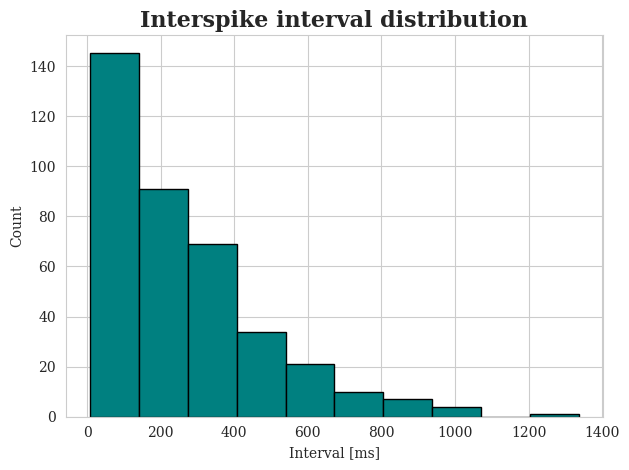

In [12]:
"""Samme som i fig 7 D-F, men med tau_fac=0 og tau_rec=800.0
Tidligere SNR(beat) = 3.8"""
plot_results(sim_time=100e3, letter_idx=3,
             a_values=[1000],f_values=[1000], delay_sd=0, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=0.0, tau_rec=800.0)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.001127,3.636516,15.61,7.34,8.43,84.64,0.96,7.64,3.87,1.1,7.6,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_170.png


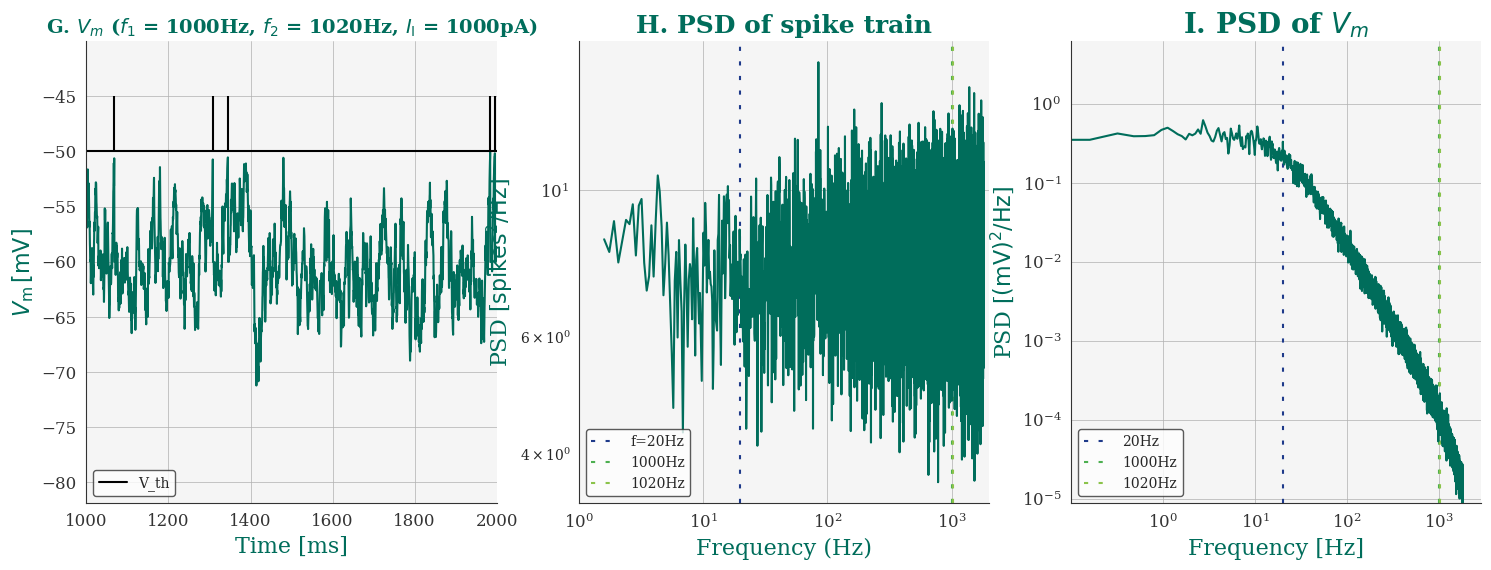

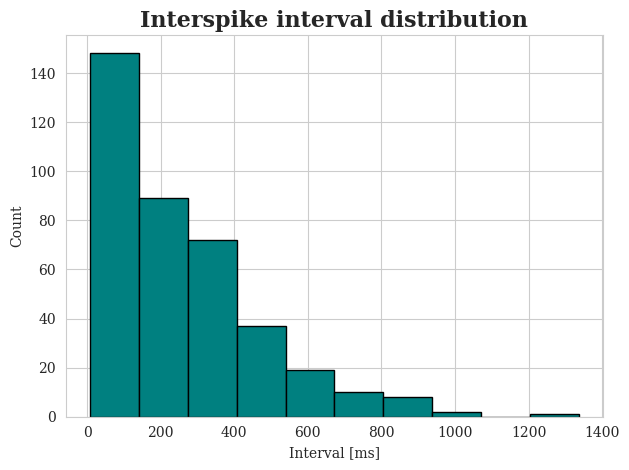

In [17]:
# fig 7 G-H - with depression
"""Samme kjøring som tidligere kjøring som i fig 7 G-H, men med tau_fac=0.0 og tau_rec=800.0
Tidligere SNR(beat) = 4.1"""
plot_results(sim_time=100e3, letter_idx=6,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=5,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=0.0, tau_rec=800.0)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.003436,3.678077,11.92,5.64,5.51,84.64,0.91,6.16,3.02,1.0,6.2,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_166.png


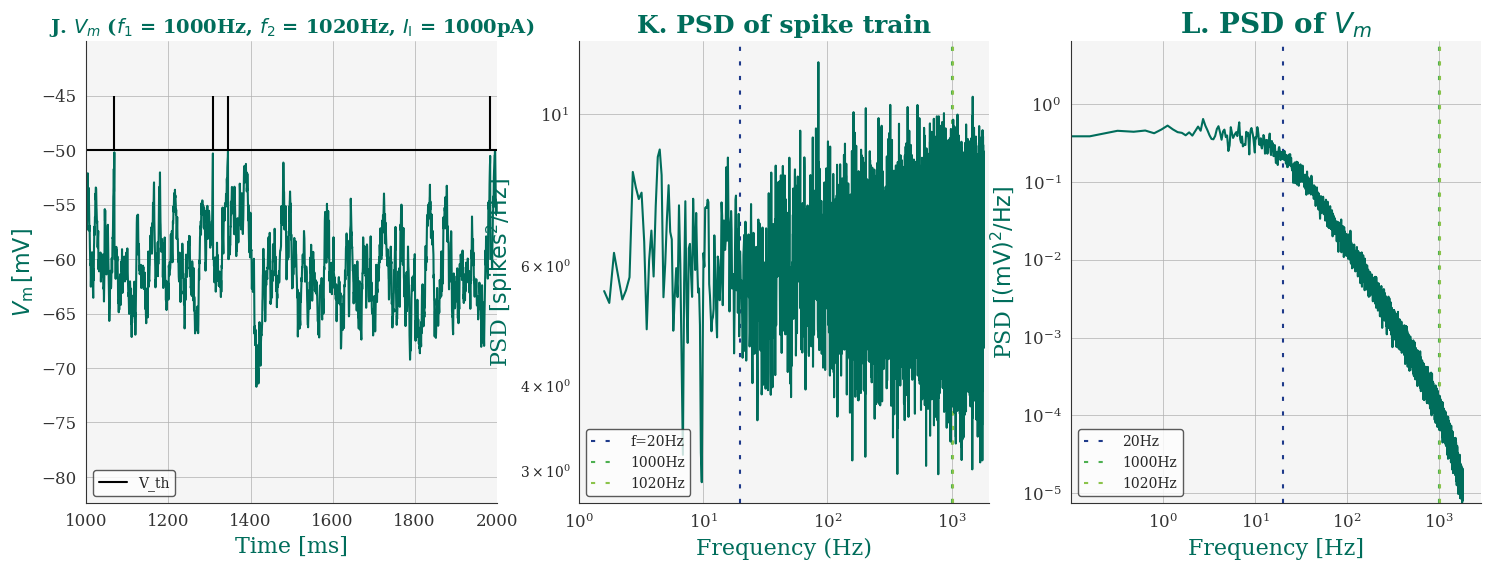

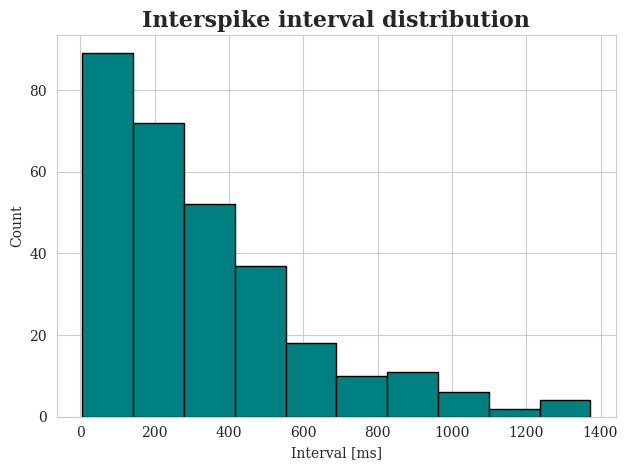

In [13]:
"""Samme kjøring som fig 7 J-L, men med tau_fac=0.0 og tau_rec=800.0
Tidligere SNR(beat) = 1.7"""
# fig 7 J-L - with depression
plot_results(sim_time=100e3, Cm=100, letter_idx=9,
             a_values=[1000],f_values=[1000], delay_sd=0, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000, tau_syn_ex=1,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=0.0, tau_rec=800.0)

### Short term facilitation

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.00005,3.266713,2392.43,148.49,27.58,20.0,1.43,104.09,52.68,43.6,104.1,5804.04


Saved plot as: /home/tonje/master/TIS/results/exc_network_153.png


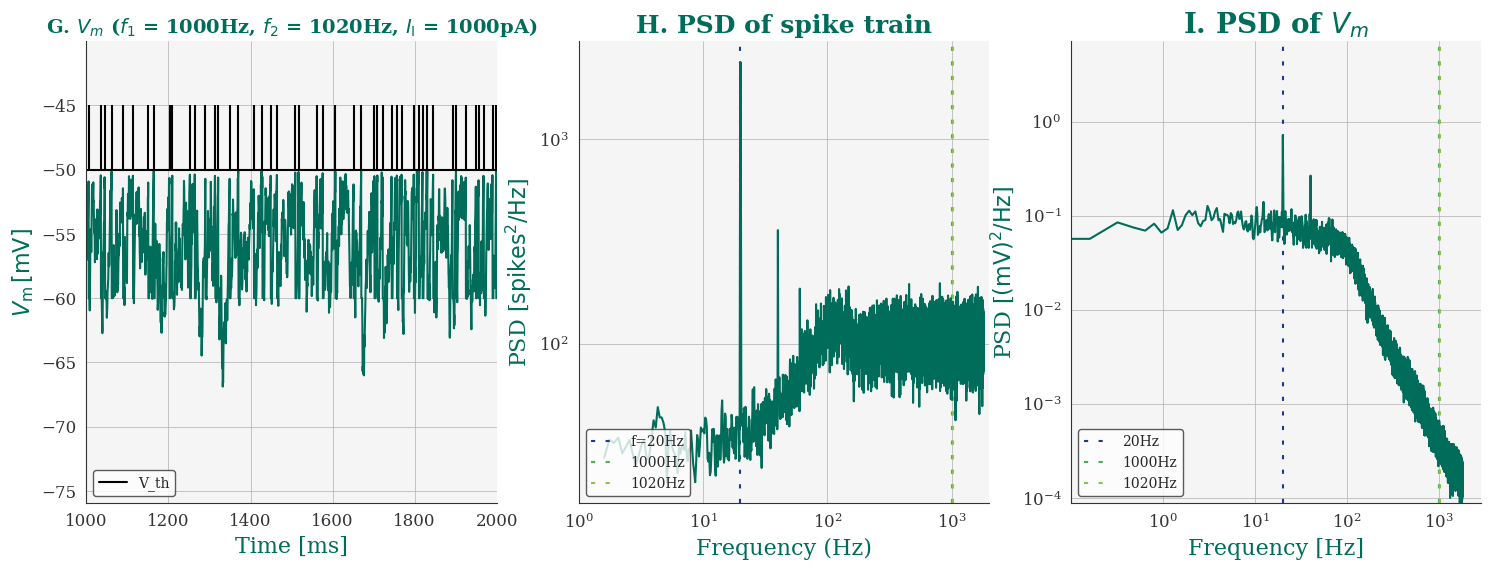

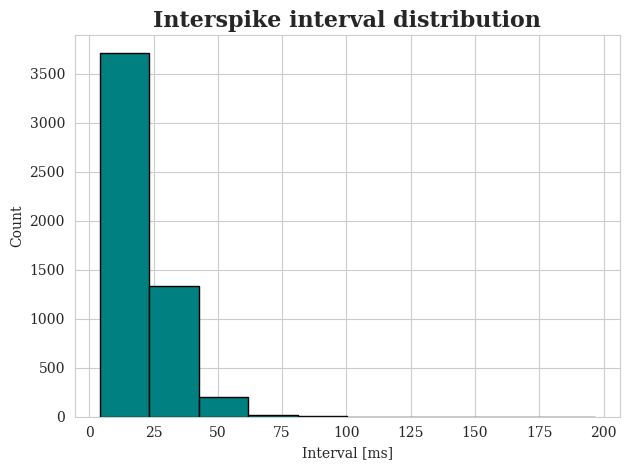

In [5]:
# fig 7 G-H
"""Samme som tidligere kjøring som i fig 7 G-H, men med tau_fac=530.0 og tau_rec=130.0
Tidligere SNR(beat) = 4.1"""
plot_results(sim_time=100e3, letter_idx=6,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=5,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000975,3.596087,17.99,10.04,8.62,1208.16,1.07,9.42,4.77,1.4,9.4,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_171.png


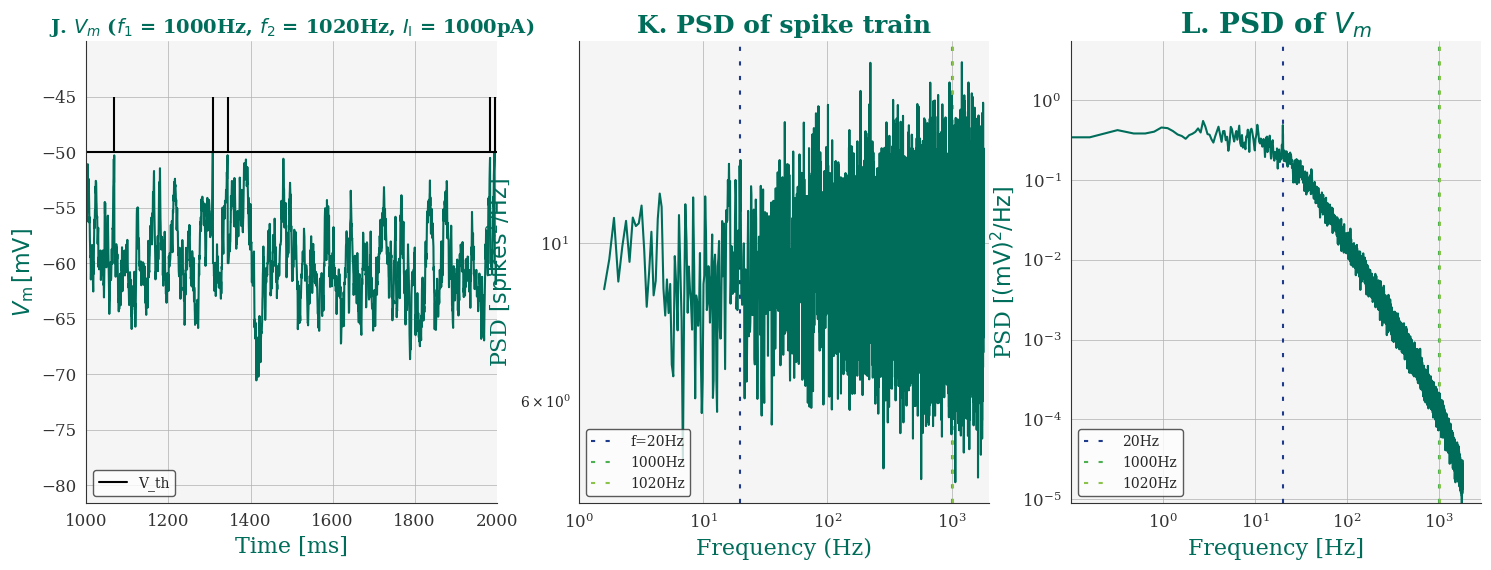

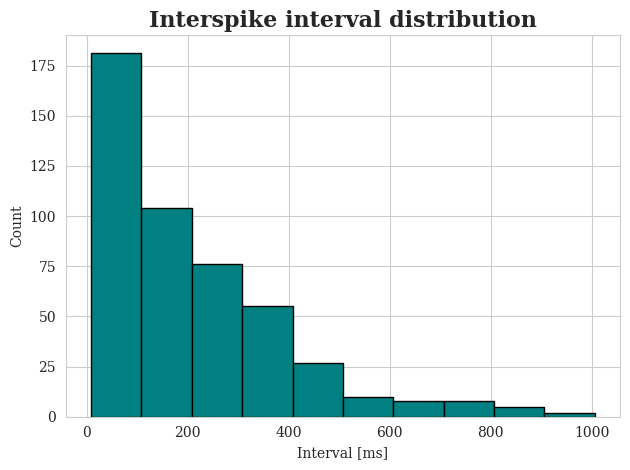

In [18]:
"""Samme kjøring som fig 7 J-L, men med tau_fac=530.0 og tau_rec=130.0 og U=0.03
Tidligere SNR(beat) = 1.7"""
# fig 7 J-L - with facilitation
plot_results(sim_time=100e3, Cm=100, letter_idx=9,
             a_values=[1000],f_values=[1000], delay_sd=0, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000, tau_syn_ex=1,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000095,3.469713,49.57,15.27,17.08,20.0,0.92,16.63,8.68,3.1,16.6,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_168.png


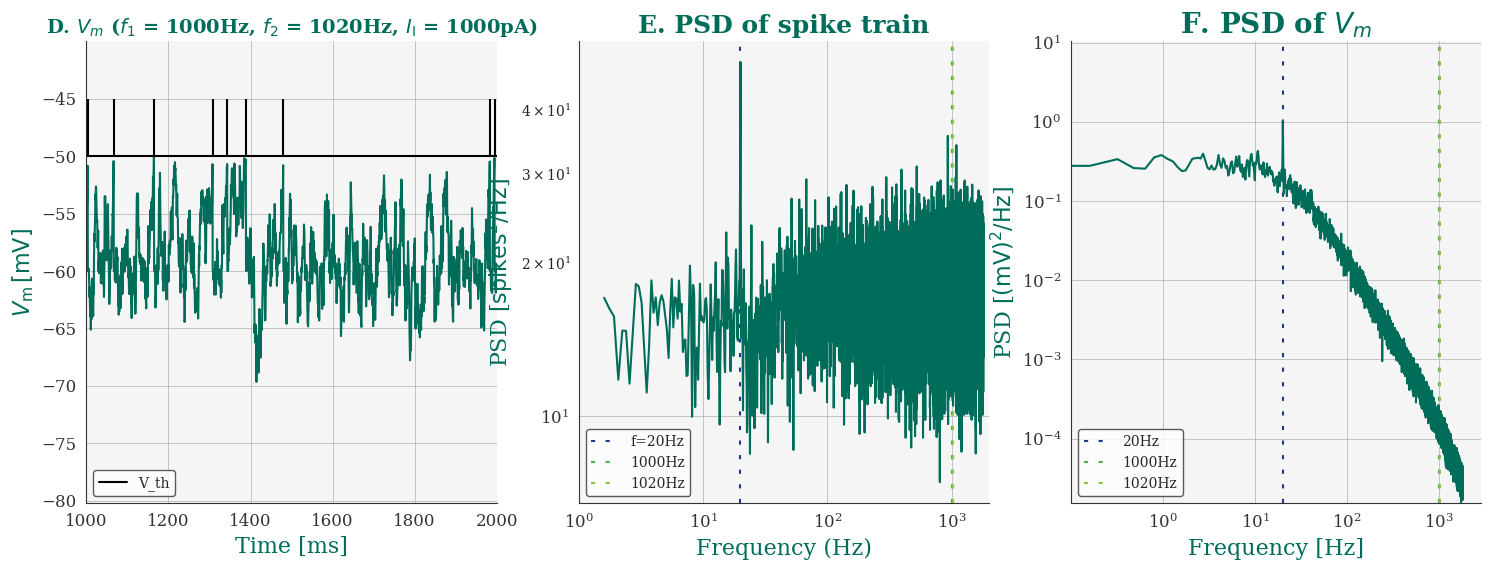

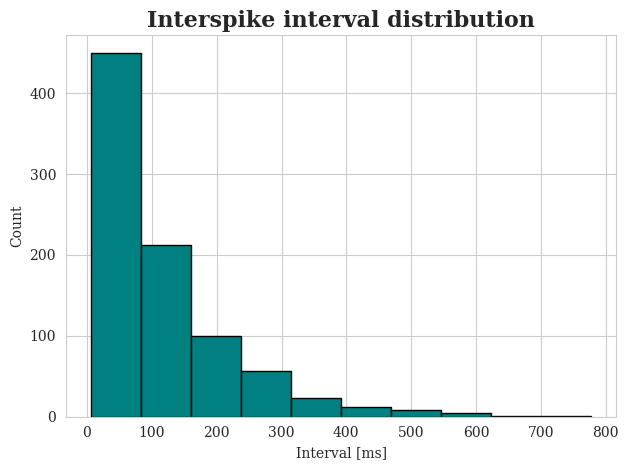

In [15]:
# fig 7 D-F, facilitation
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], delay_sd=0, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, tau_fac=530.0, tau_rec=130.0, U=0.03, welch=True, letter_idx=3)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000095,3.469713,49.57,15.27,17.08,20.0,0.92,16.63,8.68,3.1,16.6,5805.11


Saved plot as: /home/tonje/master/TIS/results/exc_network_169.png


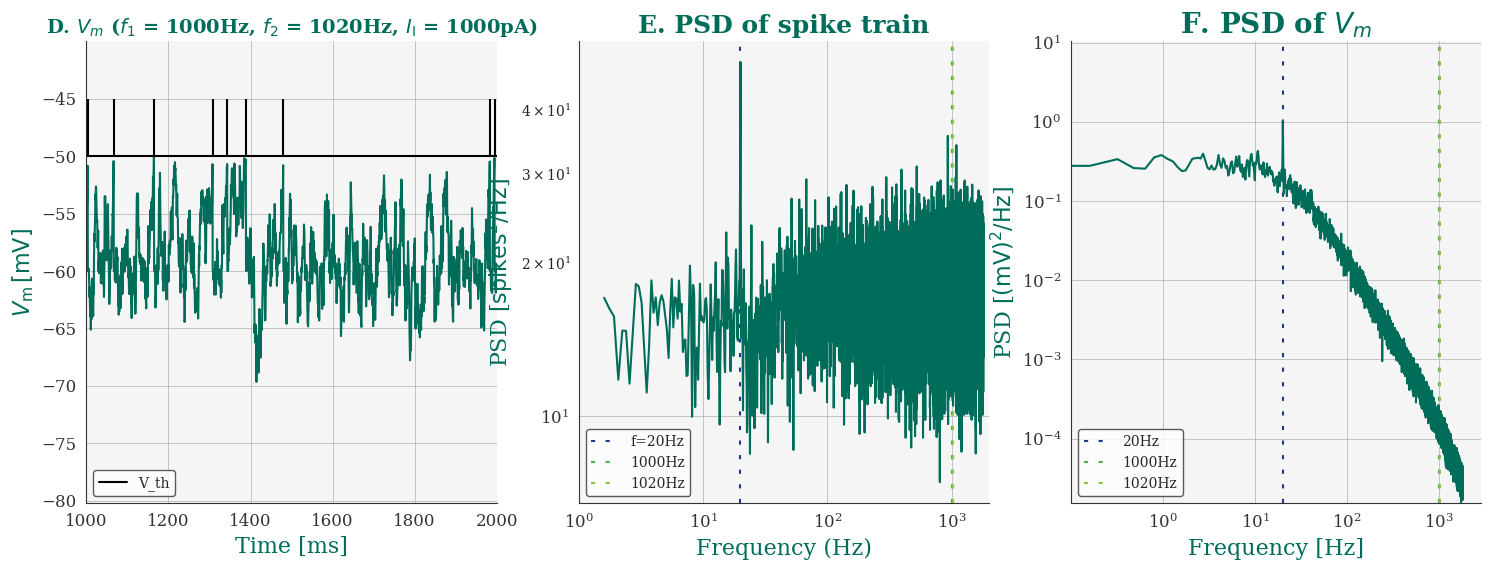

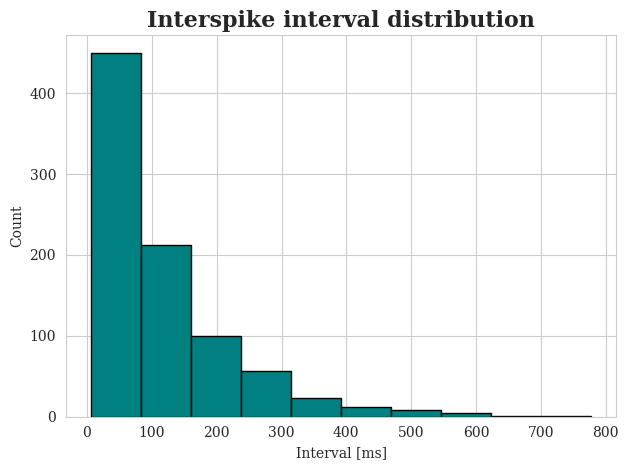

In [16]:
"""delay = 0"""
# fig 7 D-F, SD delay = 0
plot_results(sim_time=100e3, letter_idx=3,
             a_values=[1000],f_values=[1000], delay_sd=0, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000005,3.267374,2386.71,131.09,27.9,20.0,1.27,103.19,52.67,43.9,103.2,5804.04


Saved plot as: /home/tonje/master/TIS/results/exc_network_162.png


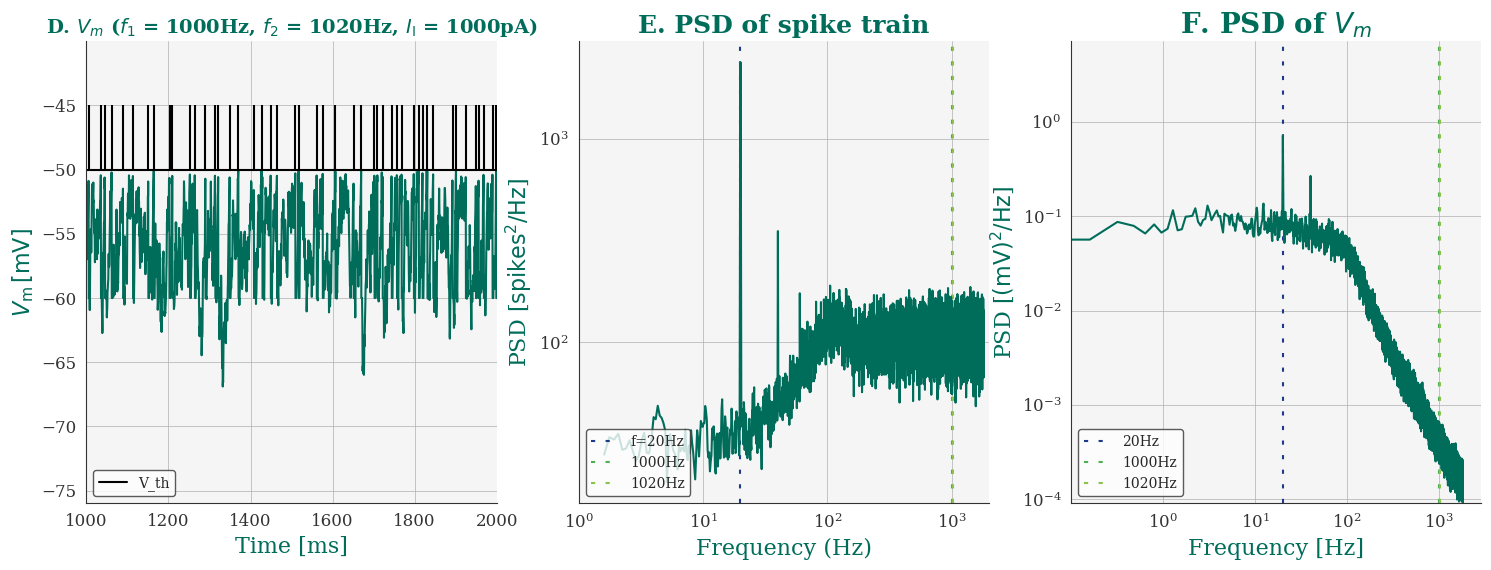

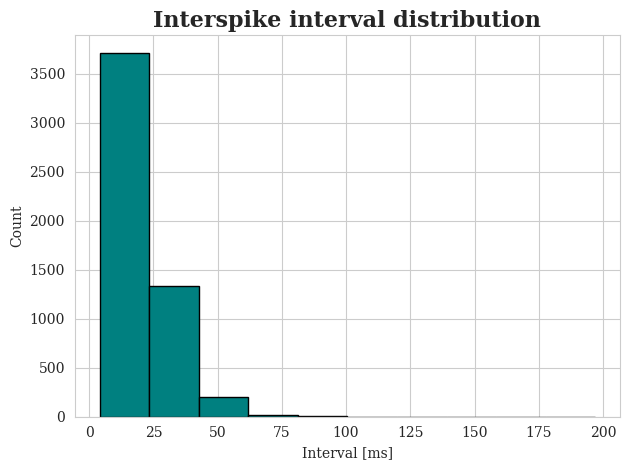

In [14]:
"""delay = 0.1"""
# fig 7 D-F, SD delay = 0
plot_results(sim_time=100e3, letter_idx=3,
             a_values=[1000],f_values=[1000], delay_sd=0.1, delay_mean=5,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000172,3.267893,2387.44,128.18,27.13,20.0,1.26,101.43,52.69,43.5,101.4,5804.04


Saved plot as: /home/tonje/master/TIS/results/exc_network_159.png


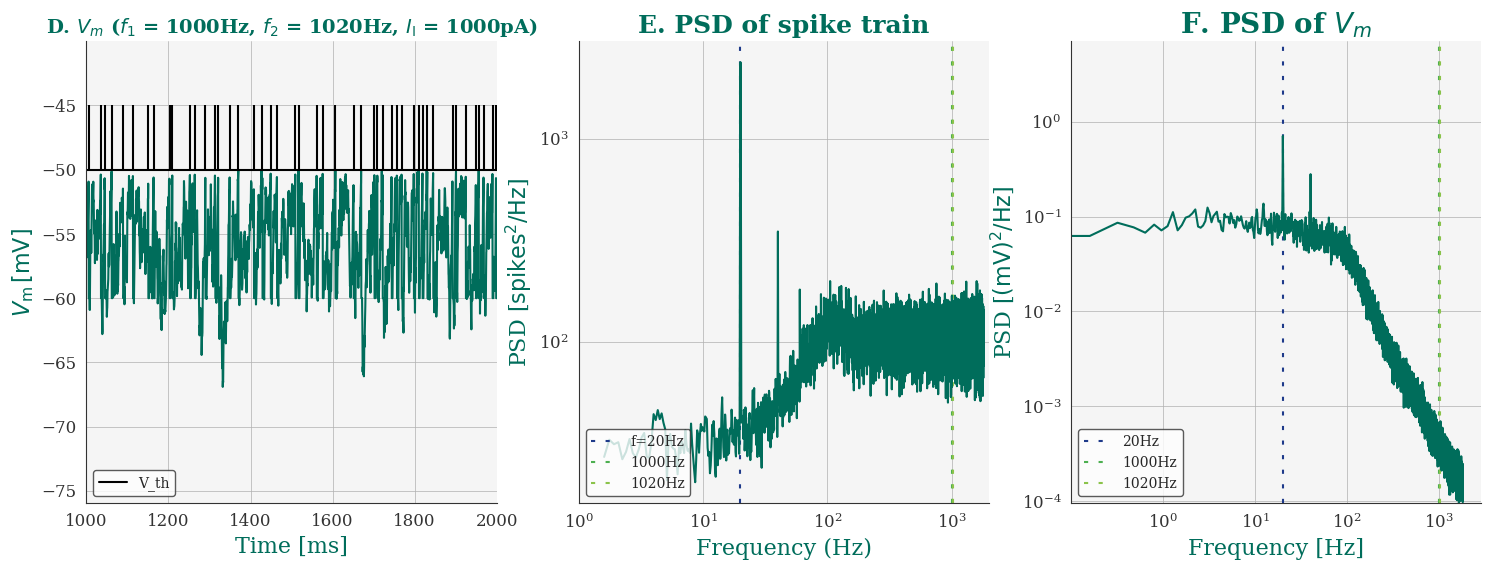

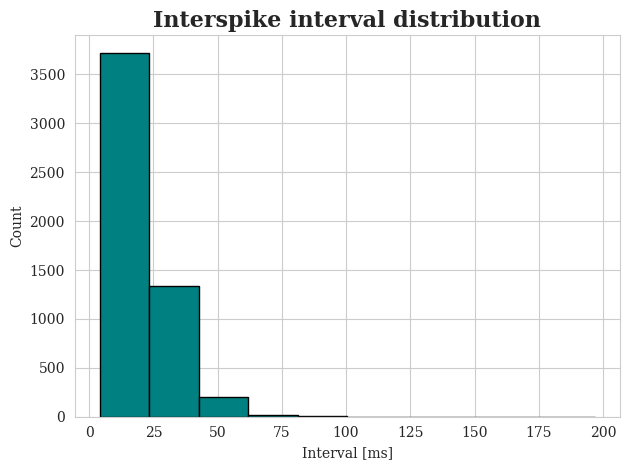

In [11]:
"""delay = 0.5"""
# fig 7 D-F, SD delay = 0
plot_results(sim_time=100e3, letter_idx=3,
             a_values=[1000],f_values=[1000], delay_sd=0.5, delay_mean=5,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

Forventer at SNR blir lav dersom vi øker delay 

siste frekvens i freq: 1799.8400000000001
arg_f: 6240
arg_f: 115


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.00019,3.177939,684.87,102.59,27.5,20.0,0.96,107.39,52.03,15.7,107.4,5804.04


Saved plot as: /home/tonje/master/TIS/results/exc_network_164.png


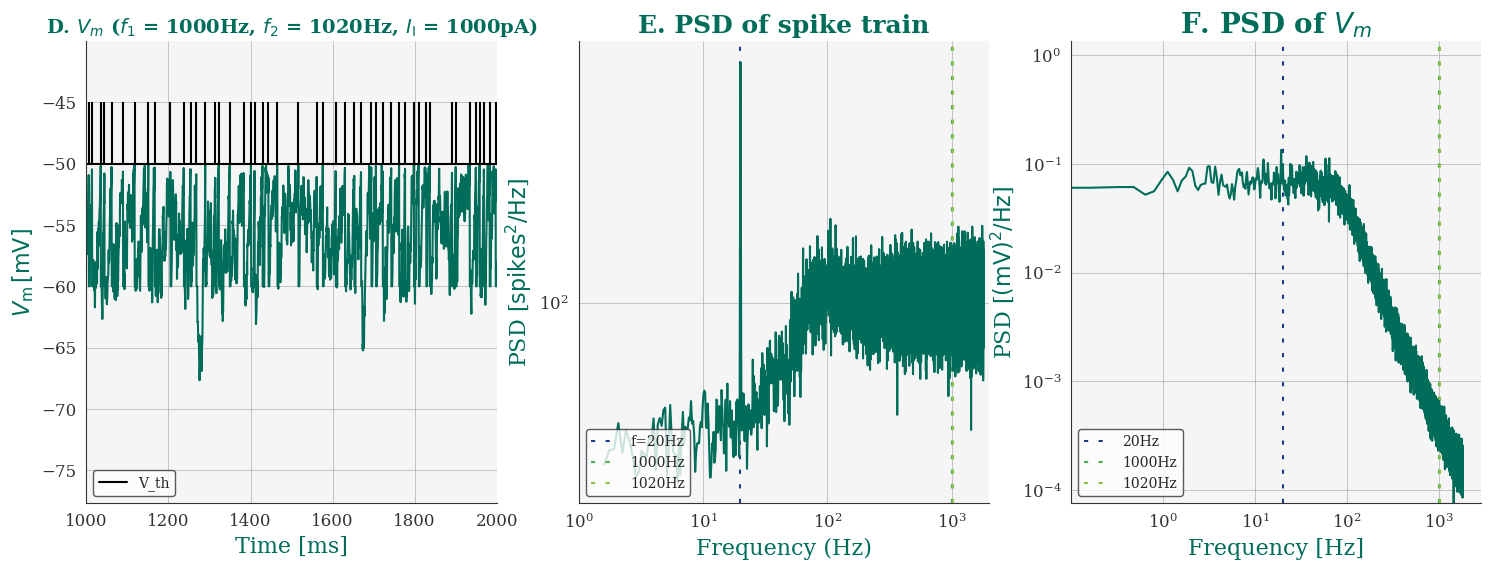

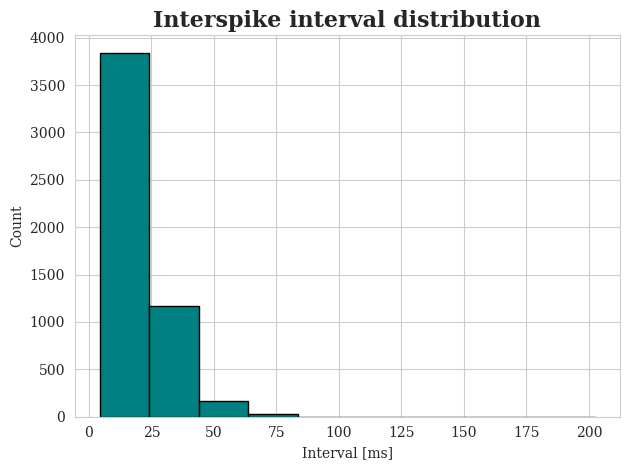

In [16]:
"""delay = 10"""
# fig 7 D-F, SD delay = 0
plot_results(sim_time=100e3, letter_idx=3,
             a_values=[1000],f_values=[1000], delay_sd=10, delay_mean=50, 
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, welch=True, tau_fac=530.0, tau_rec=130.0, U=0.03)

-------------------------------------------------------------------------------------------------

# DIFFERENT NEURON TYPES

## iaf_psc_exp


Sep 18 11:23:47 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 18 11:23:47 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000267,3.617548,16.63,9.28,7.8,531.2,1.08,8.63,4.34,1.7,8.6,5798.75


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_53.png


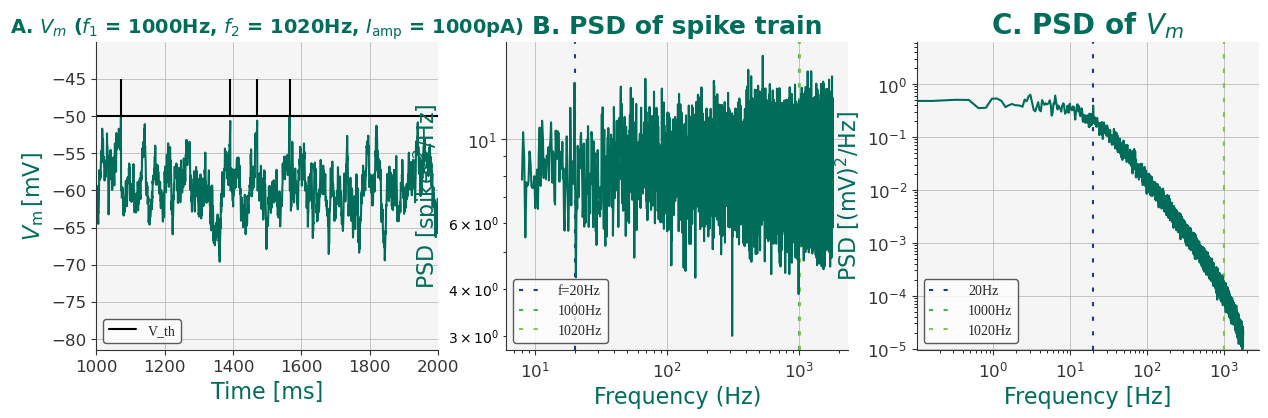

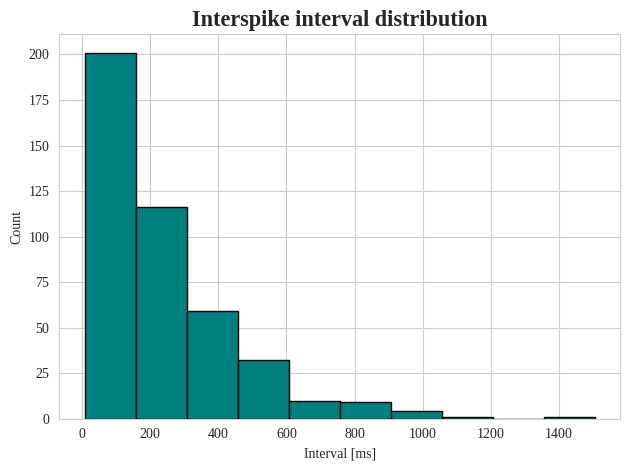

In [ ]:
"""Testing out iaf_psc_exp - exponential decay instead of alpha. delay=0.25"""

plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

## iaf_psc_alpha

siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000403,3.434559,62.39,21.36,14.0,20.0,1.08,19.79,10.05,3.5,19.8,5798.75


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_54.png


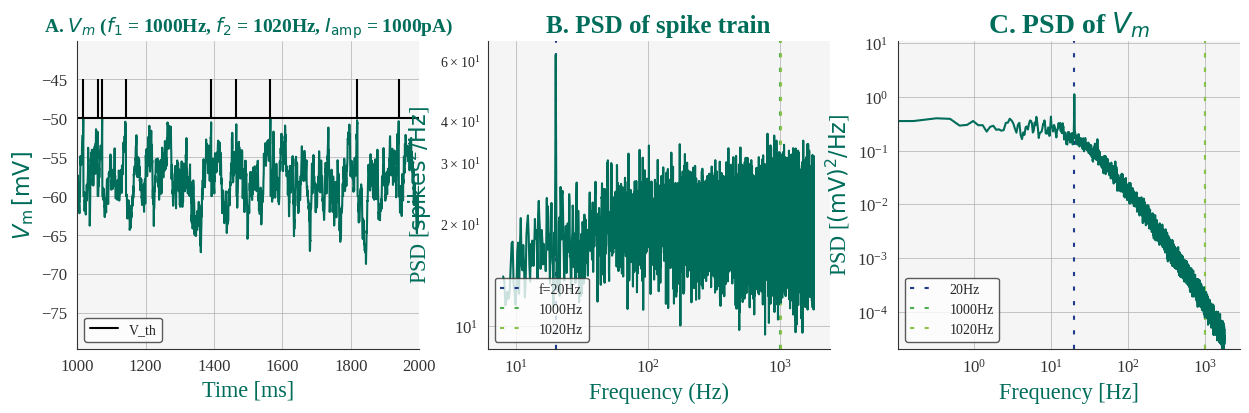

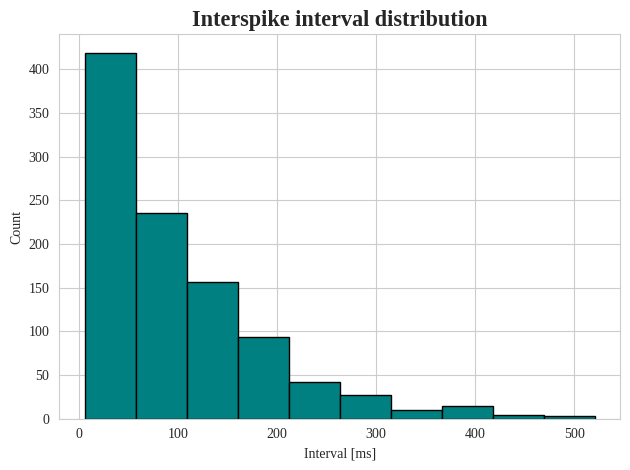

In [5]:
"""Testing out iaf_psc_exp - exponential decay instead of alpha. delay=0.25"""
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_alpha")

## iaf_cond_exp


Sep 17 18:03:18 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 17 18:03:18 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000003,3.286238,20973.88,258.87,33.04,20.0,1.11,232.71,116.43,105.7,232.7,2545.79


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_37.png


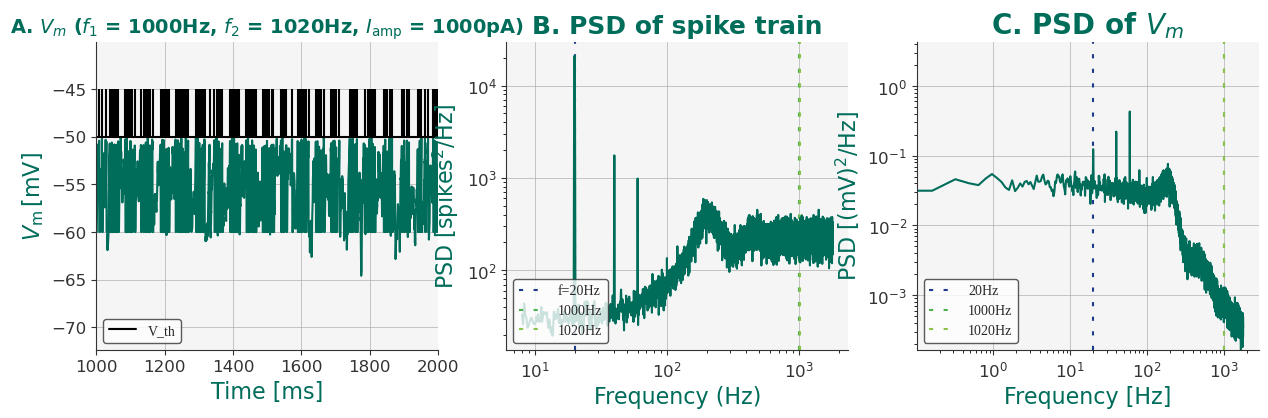

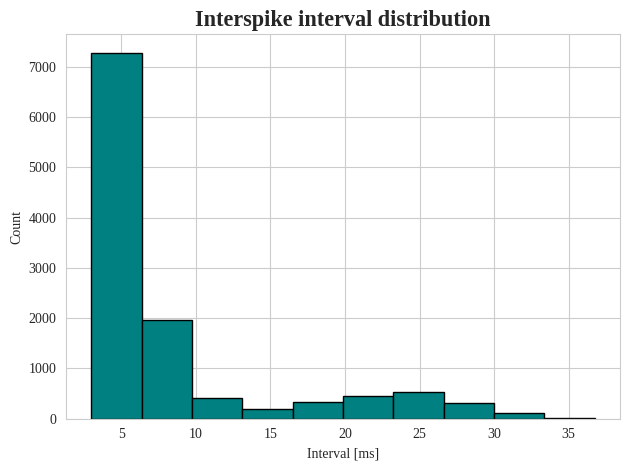

In [3]:
"""Testing out iaf_cond_exp - exponential decay instead of alpha. delay=0.25"""
plot_results(sim_time=100e3,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_cond_exp")

siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.00078,3.603785,14.99,9.35,6.78,986.08,1.18,7.92,4.17,1.2,7.9,5805.33


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_38.png


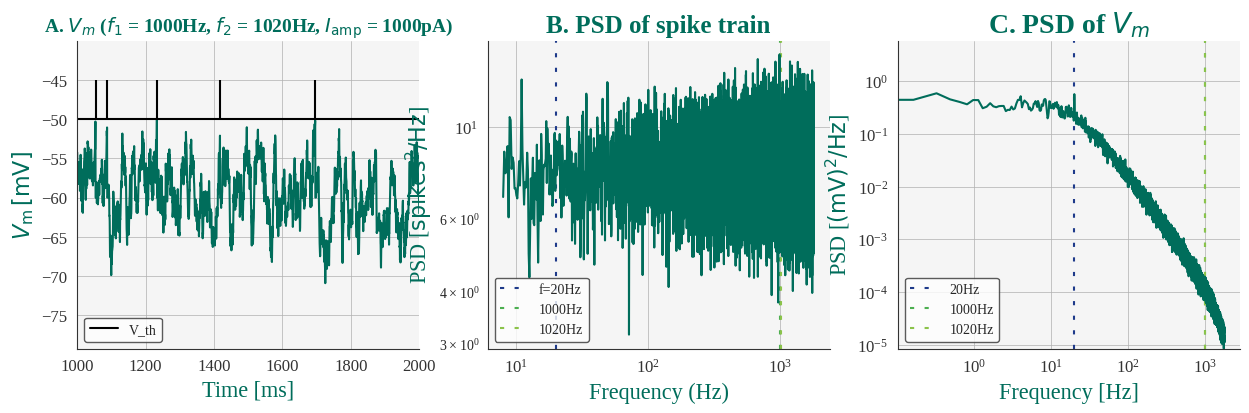

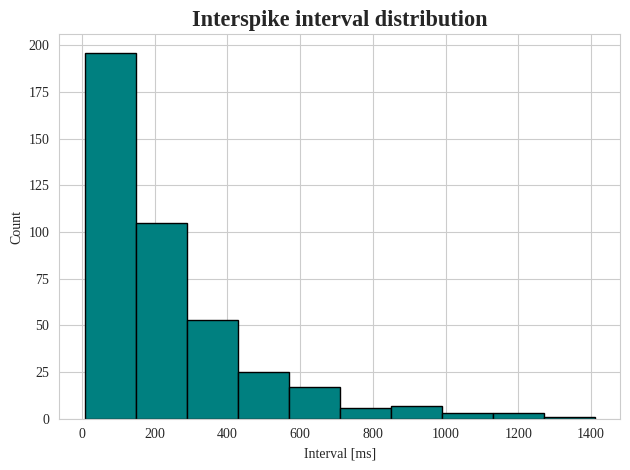

In [4]:
"""Testing iaf_psc_exp -  exponential decay instead of alpha. 
    and decreasing tau_syn_ex. delay=0.25"""

plot_results(sim_time=100e3, tau_syn_ex=2,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

## øker tau_syn_ex for å sjekke om peaks kommer tilbake


Sep 17 18:40:02 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 17 18:40:02 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.001212,3.485266,41.44,28.53,13.47,20.0,1.46,19.53,9.53,2.5,19.5,5810.24


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_42.png


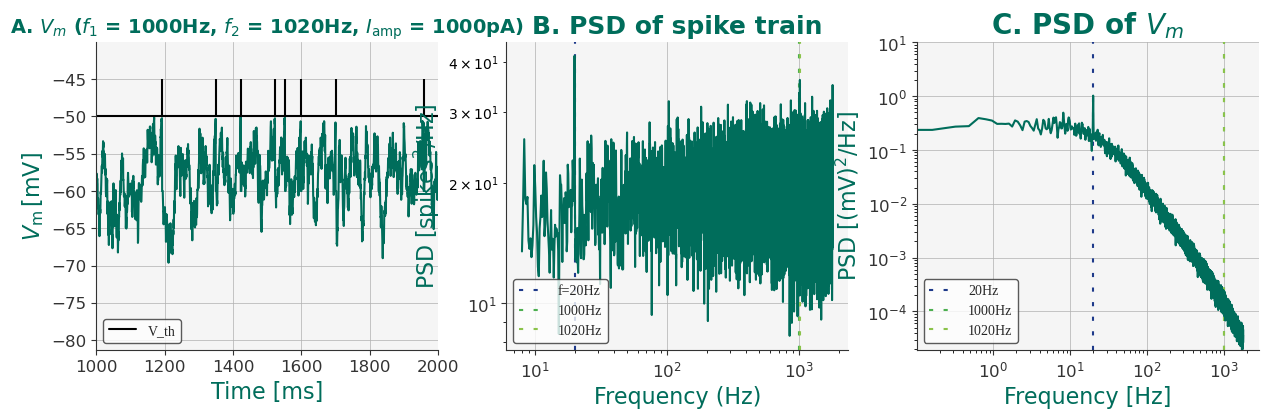

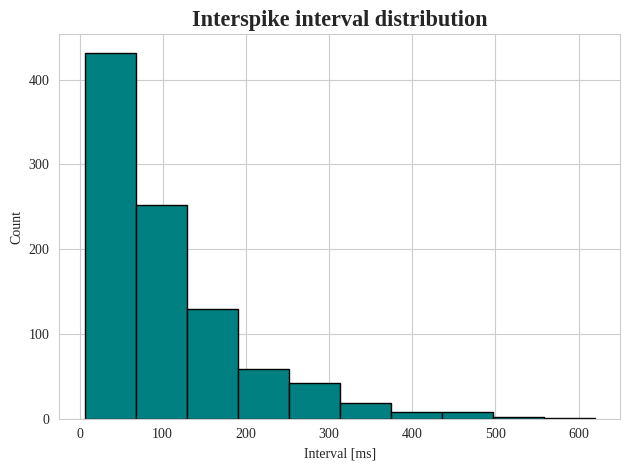

In [3]:
"""Testing iaf_psc_exp -  exponential decay instead of alpha. 
    and decreasing tau_syn_ex. delay=0.25"""

plot_results(sim_time=100e3, tau_syn_ex=5,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

## decreasing tau_syn_ex : rise time of PSC. keeping charge constant by scaling the weight by $\frac{\tau_{syn,ex,i}}{\tau_{syn,ex,f}}$

siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.001949,3.663171,15.52,10.77,9.17,946.4,1.3,8.26,4.25,1.6,8.3,5811.22


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_40.png


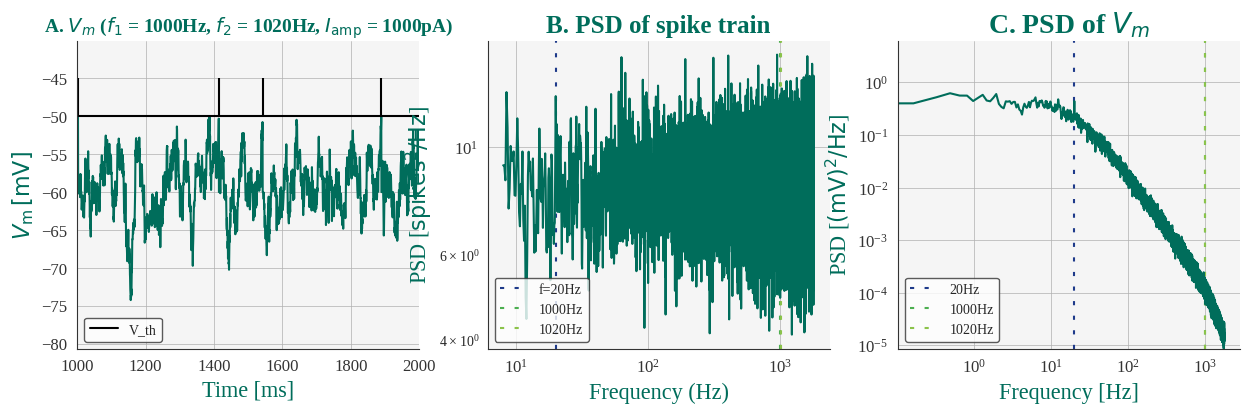

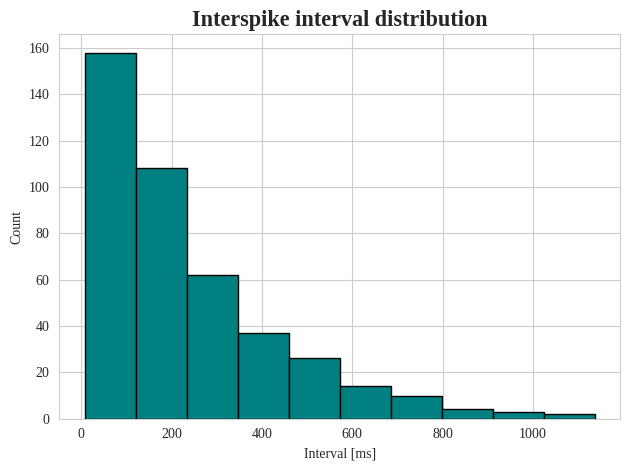

In [4]:
"""Testing iaf_psc_exp -  exponential decay instead of alpha. 
    and decreasing tau_syn_ex to 0.5 ms, scaling the weight by 4 
    to get the same amount of charge as in previous simulations.
    delay=0.25"""

plot_results(sim_time=100e3, tau_syn_ex=0.5,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=50,
             noisy=True, SD_values=[250],num_A=1000, weight=4,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000506,67.78,19.48,26.29,20.0,0.92,21.08,10.65,3.7,21.1,5804.15


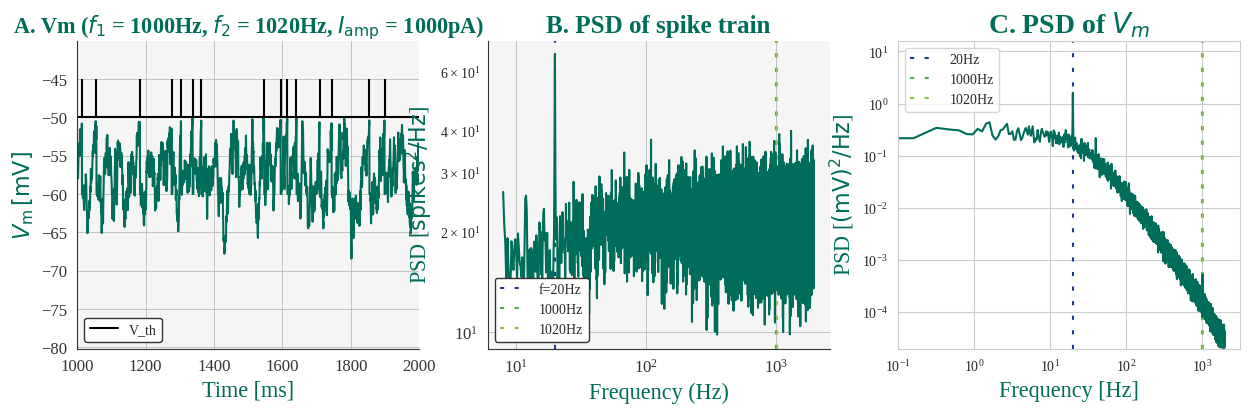

In [9]:
plot_results(sim_time=100e3, tau_syn_ex=0.1,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=50,
             noisy=True, SD_values=[250],num_A=1000, weight=20,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000352,64.41,20.68,26.3,20.0,1.03,20.1,10.49,3.6,20.1,5804.15


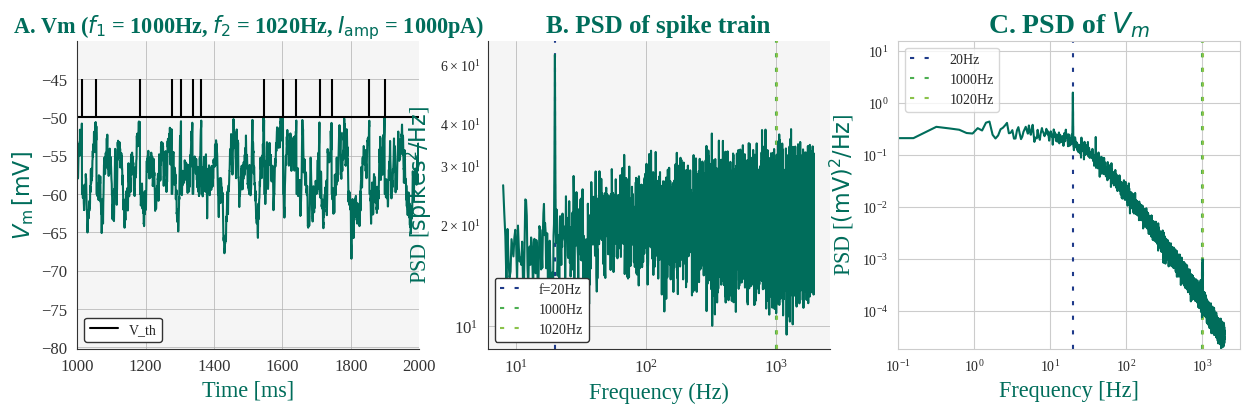

In [10]:
plot_results(sim_time=100e3, tau_syn_ex=0.01,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=50,
             noisy=True, SD_values=[250],num_A=1000, weight=200,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")

## what about the delta function?

siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000022,3.199941,15710.29,10886.51,25.1,20.0,20.14,540.47,226.59,106.6,540.5,5811.22


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_41.png


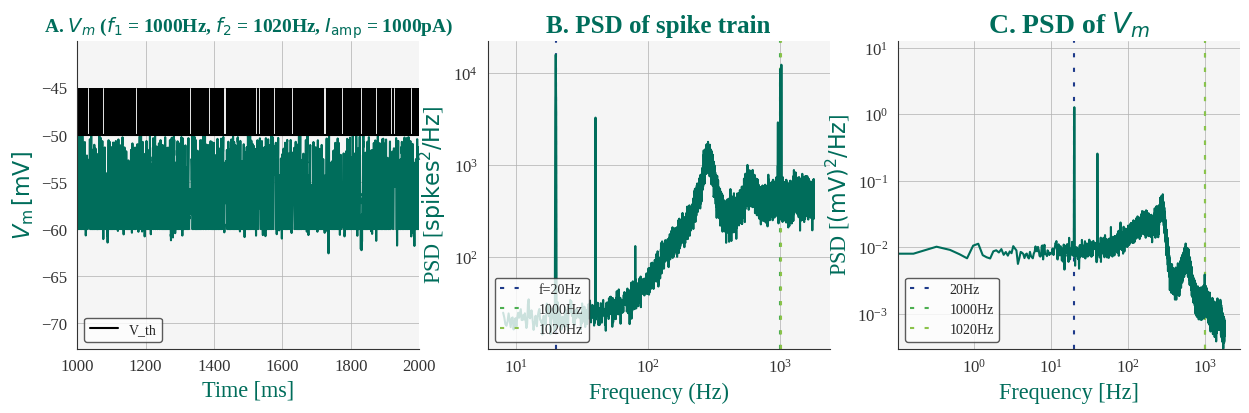

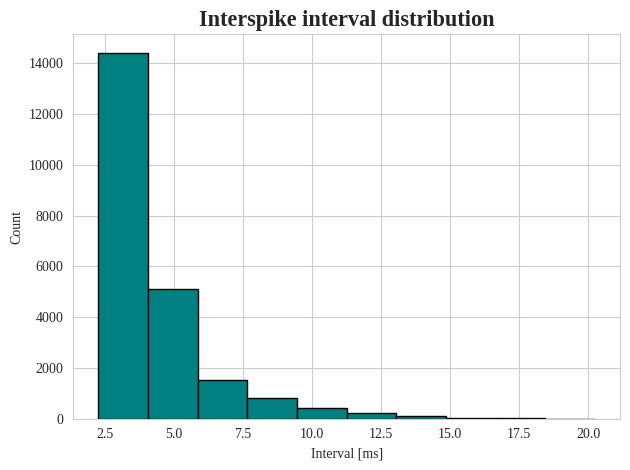

In [5]:
plot_results(sim_time=100e3, tau_syn_ex=2,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=5,
             noisy=True, SD_values=[250],num_A=1000, weight=1,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_delta")

As long as the amount of charge is held constant, the shape of the epsp does not matter. 
the charge and the delay is important to keep the signal dominance of the beat frequency. 

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000231,74.71,22.74,16.45,20.0,1.03,22.01,11.03,3.9,22.0,5811.65


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/B_main_77.png


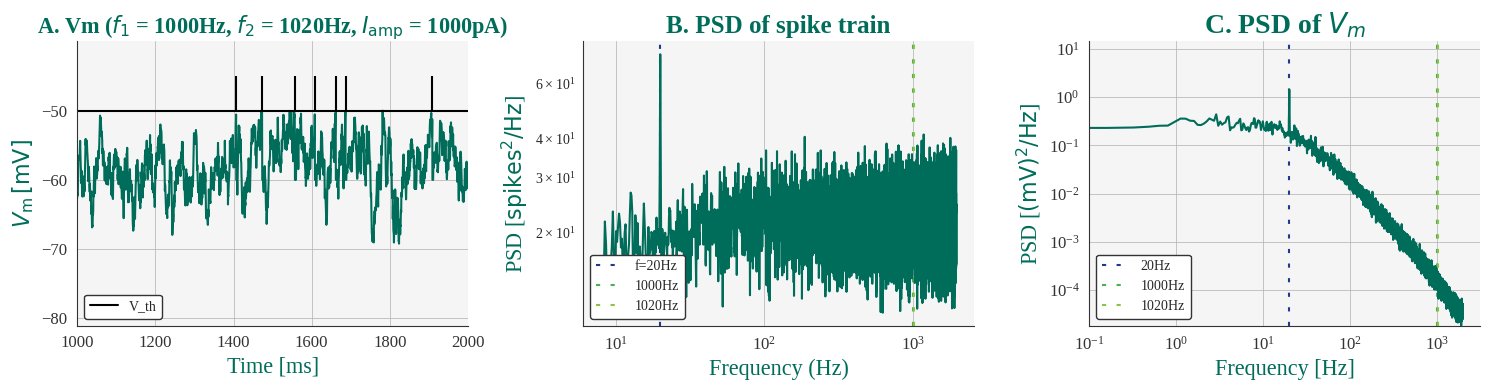

In [10]:
plot_results(sim_time=100e3, tau_syn_ex=0.5, tau_m = 0.5,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000, weight=4,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_delta")

## exploring mechanism behind TIS 
idé: bruk results["tot_ts"] (alle spike-tidene), dvs. input til postsynaptisk nevron og ta fouriertransformasjonen av dette for å se om denne inputen gir peak på 1000 Hz. vil tro at den gjør det, kan være summasjonen i postsyn. nevron som gjør at 1000 hz dempes.

In [4]:


res = build_network(Cm=100,sim_time=100e3, second_sine=True, noisy=True, 
                  f1=1000.0, a=1000.0, SD=250.0, delay_mean=1, delay_sd=0.25,
                  beat=20, neuron_type="iaf_psc_alpha")

all_spikes = res["tot_ts"]

print(f"len spike times:{len(all_spikes)}, spike_times[:10]: {all_spikes[:10]}")

freqs, psd_values = psd(res["tot_ts"], 100e3)


Sep 26 10:22:24 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 26 10:22:24 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
len spike times:580376, spike_times[:10]: [2.5  2.5  3.5  3.5  3.5  3.5  3.5  3.5  3.5  3.75]


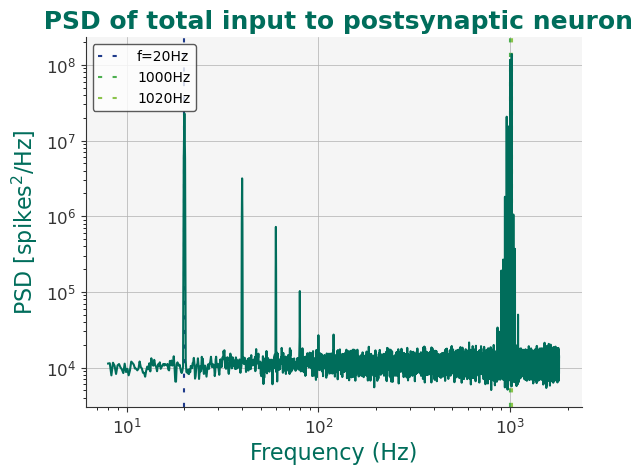

In [5]:
beat = 20
harmonics_beat = 1
harmonics = 1
second_sine = True
f = 1000

freqs = freqs[50:]
psd_values = psd_values[50:]
arg_f = np.argmin(np.abs(freqs - f))

arg_beat = np.argmin(np.abs(freqs - beat))

fig = plt.figure()
ax_fft = plt.gca()

# Vertical lines indicating harmonics, colors filled in by chat GPT
beat_colors = ["teal", "#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B", "#FF9800","#F4E91E63","#9C27B0","#673AB7", 
    "#3F51B5"] # Green colors for harmonics
        
for i in range(1,harmonics_beat+1):
    ax_fft.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"f={i*beat}Hz")
    
for i in range(1,harmonics+1):
    ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
    if second_sine:
        ax_fft.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"{i*(f+beat)}Hz")
    ax_fft.legend()

ax_fft.plot(freqs, psd_values, color="#006D5B") 

xMax = max(f,np.max(freqs))*1.1

ax_fft.set_xscale("log")
ax_fft.set_yscale("log")
# xticks and yticks
ax_fft.xaxis.set_major_locator(LogLocator(base=10.0)) 
ax_fft.yaxis.set_major_locator(LogLocator(base=10.0))
    
ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
ax_fft.set_title(f" PSD of total input to postsynaptic neuron", fontsize=18, fontweight='bold', color="#006D5B")
        
plot_layout(ax_fft, loc="upper left")



In [12]:
"""suprathreshold TIS uten noise"""
res = build_network(Cm=100,sim_time=100e3, second_sine=True, noisy=False, 
                  f1=1000.0, a=10000.0, SD=250.0, delay_mean=1, delay_sd=0.25,
                  beat=20, neuron_type="iaf_psc_alpha")

all_spikes = res["tot_ts"]

print(f"len spike times:{len(all_spikes)}, spike_times[:10]: {all_spikes[:10]}")

freqs, psd_values = psd(res["tot_ts"], 100e3)

len spike times:10000000, spike_times[:10]: [1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]


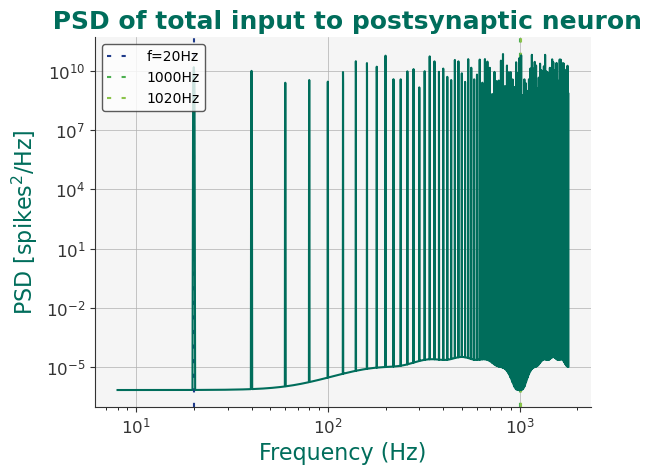

In [13]:
beat = 20
harmonics_beat = 1
harmonics = 1
second_sine = True
f = 1000

freqs = freqs[50:]
psd_values = psd_values[50:]
arg_f = np.argmin(np.abs(freqs - f))

arg_beat = np.argmin(np.abs(freqs - beat))

fig = plt.figure()
ax_fft = plt.gca()

# Vertical lines indicating harmonics, colors filled in by chat GPT
beat_colors = ["teal", "#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B", "#FF9800","#F4E91E63","#9C27B0","#673AB7", 
    "#3F51B5"] # Green colors for harmonics
        
for i in range(1,harmonics_beat+1):
    ax_fft.axvline(i*beat, linestyle="--", dashes=(2, 5), color=beat_colors[i], label=f"f={i*beat}Hz")
    
for i in range(1,harmonics+1):
    ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
    if second_sine:
        ax_fft.axvline(i*(f+beat), linestyle="--", dashes=(2, 5), color=colors[i+harmonics], label=f"{i*(f+beat)}Hz")
    ax_fft.legend()

ax_fft.plot(freqs, psd_values, color="#006D5B") 

xMax = max(f,np.max(freqs))*1.1

ax_fft.set_xscale("log")
ax_fft.set_yscale("log")
# xticks and yticks
ax_fft.xaxis.set_major_locator(LogLocator(base=10.0)) 
ax_fft.yaxis.set_major_locator(LogLocator(base=10.0))
    
ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
ax_fft.set_title(f" PSD of total input to postsynaptic neuron", fontsize=18, fontweight='bold', color="#006D5B")
        
plot_layout(ax_fft, loc="upper left")



siste frekvens i freq: 1799.8400000000001


,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),SD Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000098,3.981492,152.45,125.21,13.78,1020.0,11.46,10.93,5.68,3.8,10.9,5805.18


Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_67.png


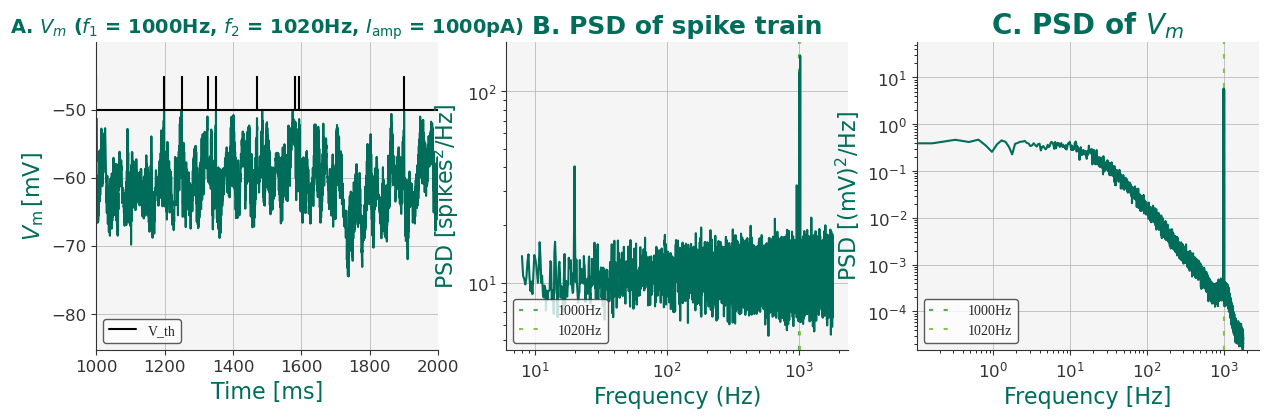

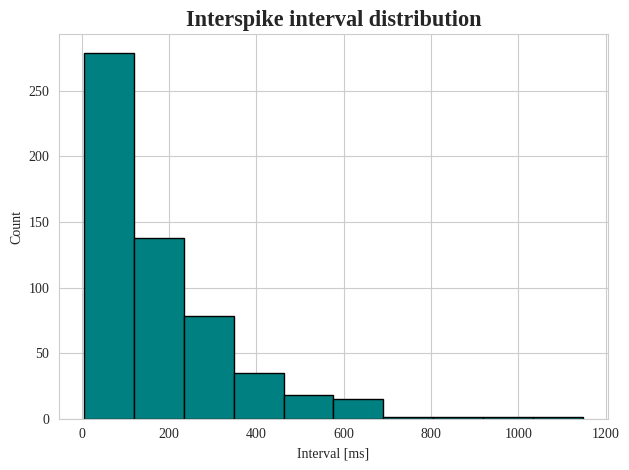

In [7]:
"""til sammenlikning: én A-celle"""

plot_results(sim_time=100e3, tau_syn_ex=2, tau_m = 10, measure_from_A=True,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1000, weight=1,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, 
             log=True, resolution=0.25, neuron_type="iaf_psc_alpha")

Er 1000 hz peaken høy fordi den inneholder så mye innhold fra 20 hz? hvordan blir FFT av totalinnholdet for 1000 Hz?

In [3]:
res = build_network(Cm=100,sim_time=100e3, second_sine=False, noisy=True, 
                  f1=1000.0, a=1000.0, SD=250.0, delay_mean=1, delay_sd=0.25,
                  neuron_type="iaf_psc_alpha")

all_spikes = res["tot_ts"]

print(f"len spike times:{len(all_spikes)}, spike_times[:10]: {all_spikes[:10]}")

freqs, psd_values = psd(res["tot_ts"], 100e3)


Sep 26 11:30:42 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.1 to 0.25 ms

Sep 26 11:30:42 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.25 ms.
len spike times:397937, spike_times[:10]: [3.75 4.75 4.75 5.5  5.5  5.5  5.5  5.75 5.75 5.75]


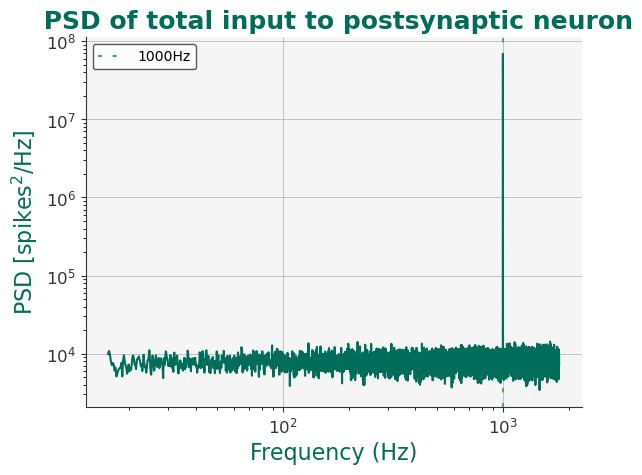

In [5]:
harmonics = 1
second_sine = True
f = 1000

freqs = freqs[50:]
psd_values = psd_values[50:]

fig = plt.figure()
ax_fft = plt.gca()

# Vertical lines indicating harmonics, colors filled in by chat GPT
beat_colors = ["teal", "#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B", "#FF9800","#F4E91E63","#9C27B0","#673AB7", 
    "#3F51B5"] # Green colors for harmonics
        

for i in range(1,harmonics+1):
    ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
    ax_fft.legend()

ax_fft.plot(freqs, psd_values, color="#006D5B") 

xMax = max(f,np.max(freqs))*1.1

ax_fft.set_xscale("log")
ax_fft.set_yscale("log")
# xticks and yticks
ax_fft.xaxis.set_major_locator(LogLocator(base=10.0)) 
ax_fft.yaxis.set_major_locator(LogLocator(base=10.0))
    
ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
ax_fft.set_title(f" PSD of total input to postsynaptic neuron", fontsize=18, fontweight='bold', color="#006D5B")
        
plot_layout(ax_fft, loc="upper left")



In [6]:
res = build_network(Cm=100,sim_time=100e3, second_sine=False, noisy=False, 
                  f1=1000.0, a=10000.0, SD=250.0, delay_mean=1, delay_sd=0.25,
                  neuron_type="iaf_psc_alpha")

all_spikes = res["tot_ts"]

print(f"len spike times:{len(all_spikes)}, spike_times[:10]: {all_spikes[:10]}")

freqs, psd_values = psd(res["tot_ts"], 100e3)

len spike times:5556000, spike_times[:10]: [1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]


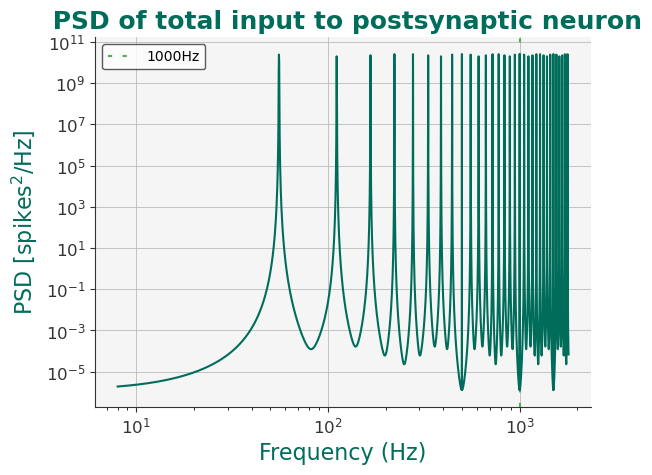

In [7]:
harmonics = 1
second_sine = True
f = 1000

freqs = freqs[50:]
psd_values = psd_values[50:]

fig = plt.figure()
ax_fft = plt.gca()

# Vertical lines indicating harmonics, colors filled in by chat GPT
beat_colors = ["teal", "#1E3A8A", "#2563EB", "#60A5FA", "#38BDF8"] #Blue colors for beat frequencies
colors = ["#009879", "#4CAF50", "#8BC34A", "#CDDC39", "#FFEB3B", "#FF9800","#F4E91E63","#9C27B0","#673AB7", 
    "#3F51B5"] # Green colors for harmonics
        

for i in range(1,harmonics+1):
    ax_fft.axvline(i*f, linestyle="--", dashes=(2, 5), color=colors[i], label=f"{i*f}Hz")
    ax_fft.legend()

ax_fft.plot(freqs, psd_values, color="#006D5B") 

xMax = max(f,np.max(freqs))*1.1

ax_fft.set_xscale("log")
ax_fft.set_yscale("log")
# xticks and yticks
ax_fft.xaxis.set_major_locator(LogLocator(base=10.0)) 
ax_fft.yaxis.set_major_locator(LogLocator(base=10.0))
    
ax_fft.set_xlabel("Frequency (Hz)", color="#006D5B", fontsize=16)
ax_fft.set_ylabel(r'PSD [$\mathrm{spikes}^2/\mathrm{Hz}$]', color="#006D5B", fontsize=16)
ax_fft.set_title(f" PSD of total input to postsynaptic neuron", fontsize=18, fontweight='bold', color="#006D5B")
        
plot_layout(ax_fft, loc="upper left")



## iaf_psc_alpha - does noise play a key role in the biophysical mechanism? 

/tmp/ipykernel_609/1889300356.py:171: UserWarning:Data has no positive values, and therefore cannot be log-scaled.


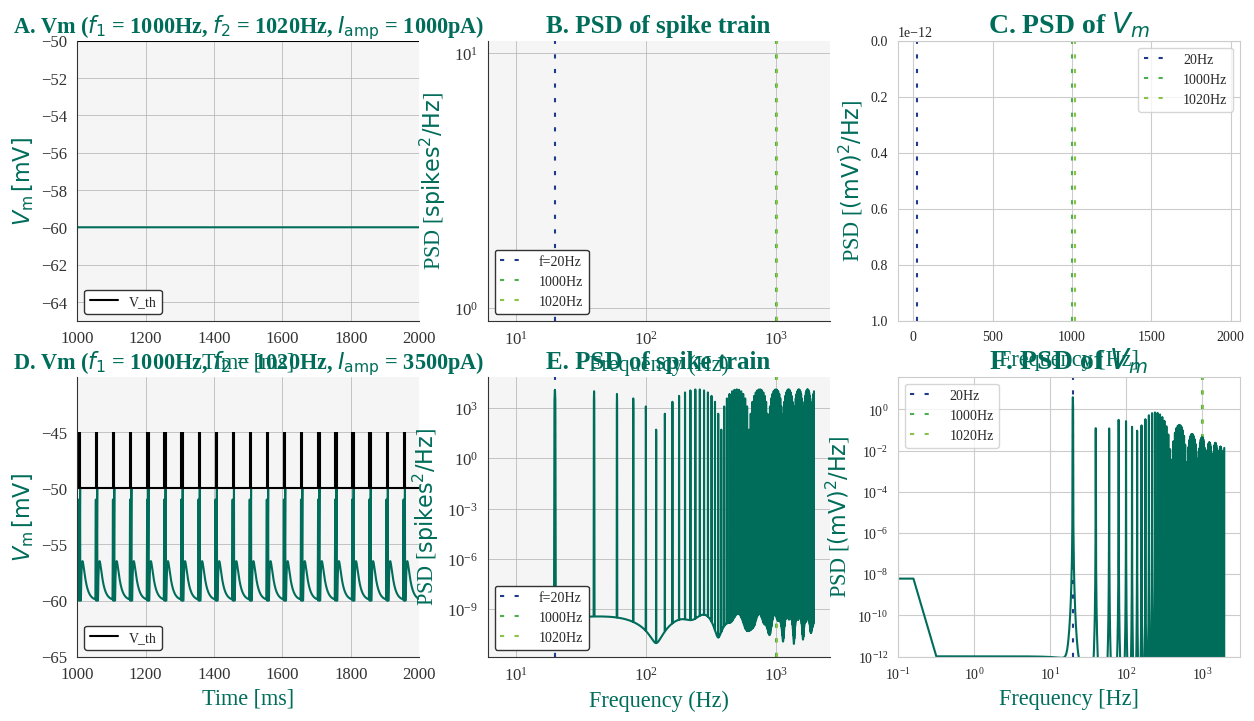

In [21]:
"""Common noise. iaf_psc_alpha. delay=0.25"""
plot_results(sim_time=100e3, tau_syn_ex=2, tau_m = 10,
             a_values=[1000,3500],f_values=[1000], delay_sd=0, delay_mean=10,
             noisy=False, SD_values=[250],num_A=1000, weight=1, common_noise=True,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25)

(Det er ulik støy i hver presynaptisk celle som fører til attenuation av høye frekvenser)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000969,7.84,4.05,3.32,1448.48,0.89,4.56,2.23,0.9,4.6,5.37


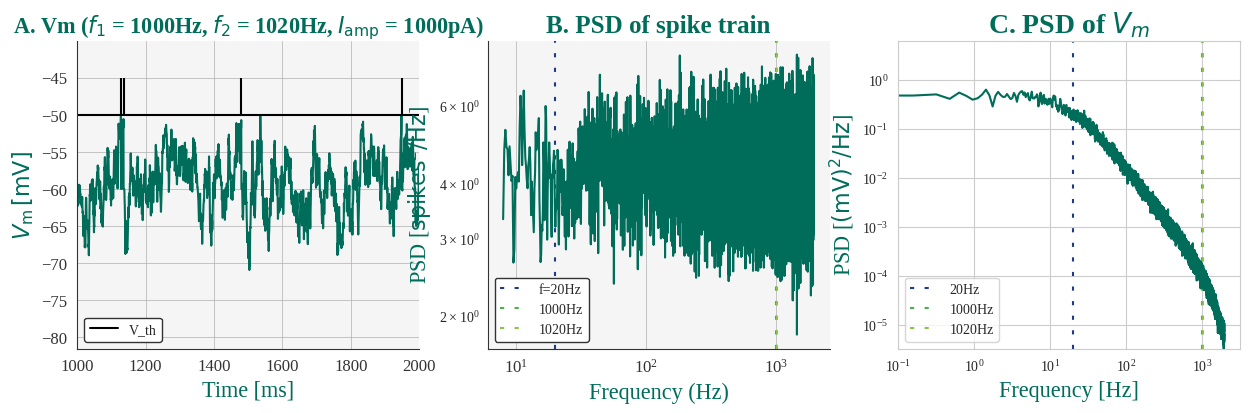

In [14]:
"""num_A=1"""
plot_results(sim_time=100e3, tau_syn_ex=2, tau_m = 10,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=1, weight=1, common_noise=False,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.001138,10.58,5.85,4.18,765.44,1.02,5.71,2.82,1.0,5.7,579.63


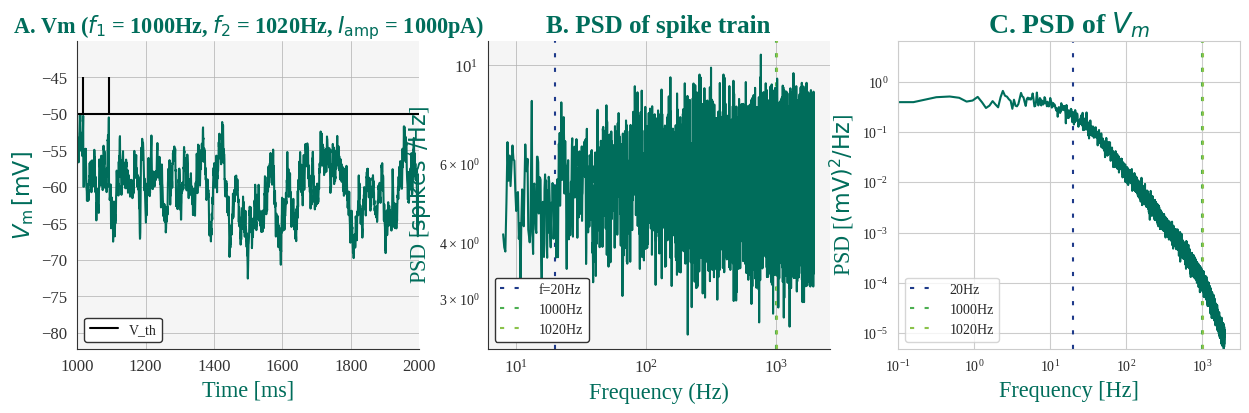

In [17]:
"""num_A=100"""
plot_results(sim_time=100e3, tau_syn_ex=2, tau_m = 10,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=100, weight=1, common_noise=False,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25)

,Input Frequency (Hz),Beat Frequency (Hz),Current Amplitude (pA),Max Vm (mV),Max FFT Amplitude [(spikes per sec)/Hz],PSD Amplitude for f [(spikes pr sec)/Hz],PSD Amplitude for f2-f1 [(spikes pr sec)/Hz],Frequency at max (Hz),SNR (f),noise average,Spike Rate (spikes/s),SNR (beat),noise average (beat),Population spike-rate
0,"[1000, 1020]",20,1000,-50.000027,11699.48,384.42,14.14,20.0,1.2,320.82,155.71,101.7,320.8,58080.45


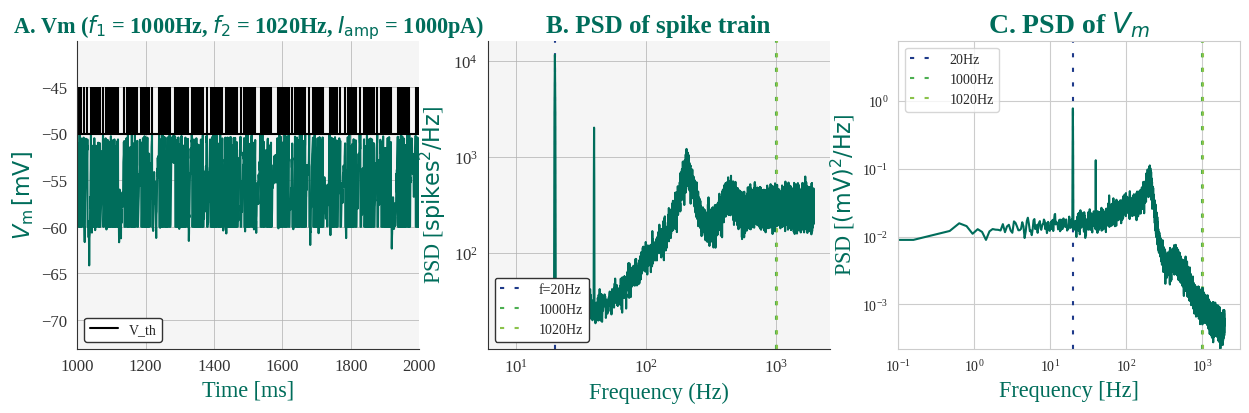

In [18]:
"""num_A=10000"""
plot_results(sim_time=100e3, tau_syn_ex=2, tau_m = 10,
             a_values=[1000],f_values=[1000], delay_sd=0.25, delay_mean=1,
             noisy=True, SD_values=[250],num_A=10000, weight=1, common_noise=False,
             bin_size=0.25,xLim=1,second_sine=True, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25)

In [ ]:
### en ac-gen. null noise

siste frekvens i freq: 809.6
Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_52.png


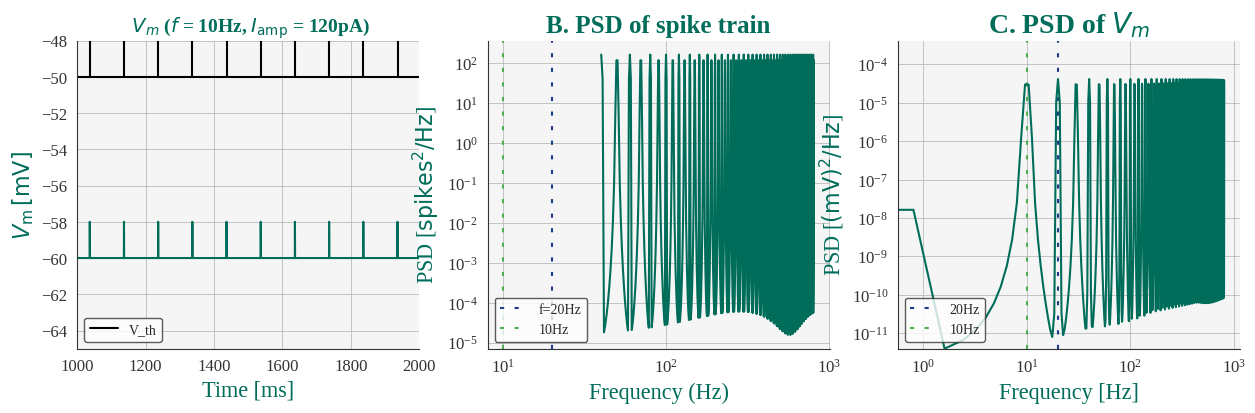

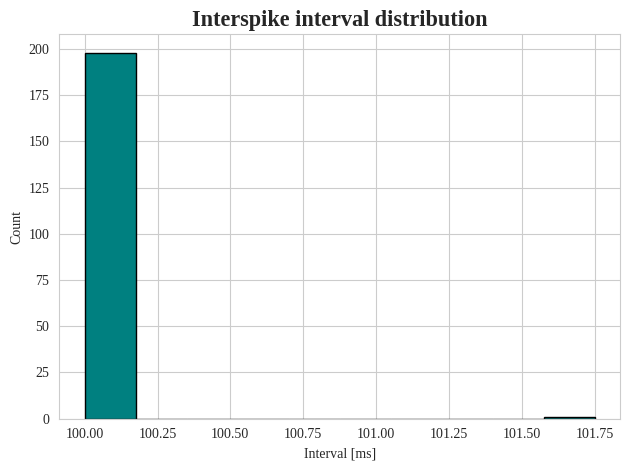

In [14]:
plot_results(sim_time=20e3, tau_syn_ex=2, 
             a_values=[120],f_values=[10], delay_sd=0.25, delay_mean=5,
             noisy=False, SD_values=[250],num_A=1000, weight=1,
             bin_size=0.25,xLim=1,second_sine=False, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_delta")

siste frekvens i freq: 809.6
Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_51.png


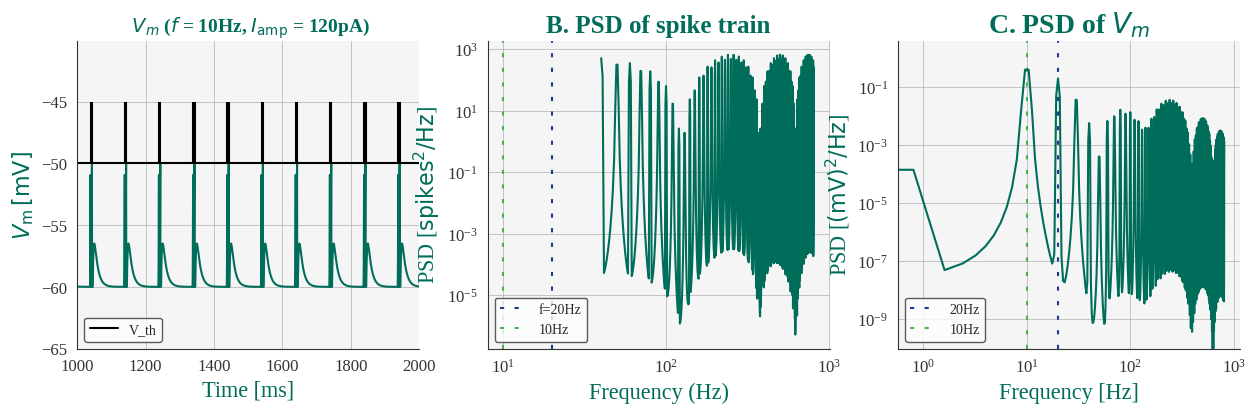

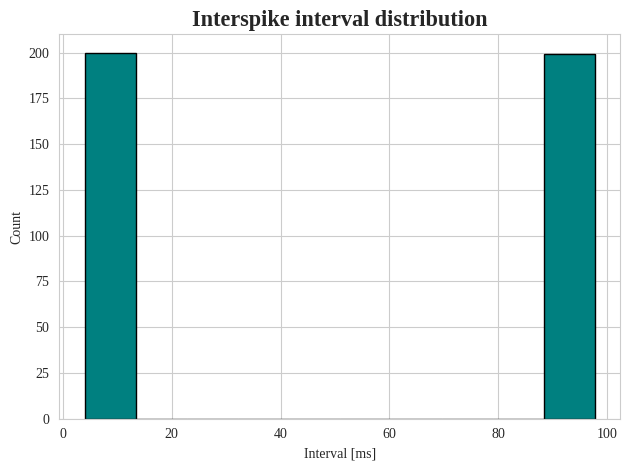

In [12]:
plot_results(sim_time=20e3, tau_syn_ex=2, 
             a_values=[120],f_values=[10], delay_sd=0.25, delay_mean=5,
             noisy=False, SD_values=[250],num_A=1000, weight=1,
             bin_size=0.25,xLim=1,second_sine=False, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_alpha")

siste frekvens i freq: 809.6
Saved plot as: /mnt/user/shared/Tonjes_CompNeuro/comp_neuro_course/master/notebooks/results/exc_network_50.png


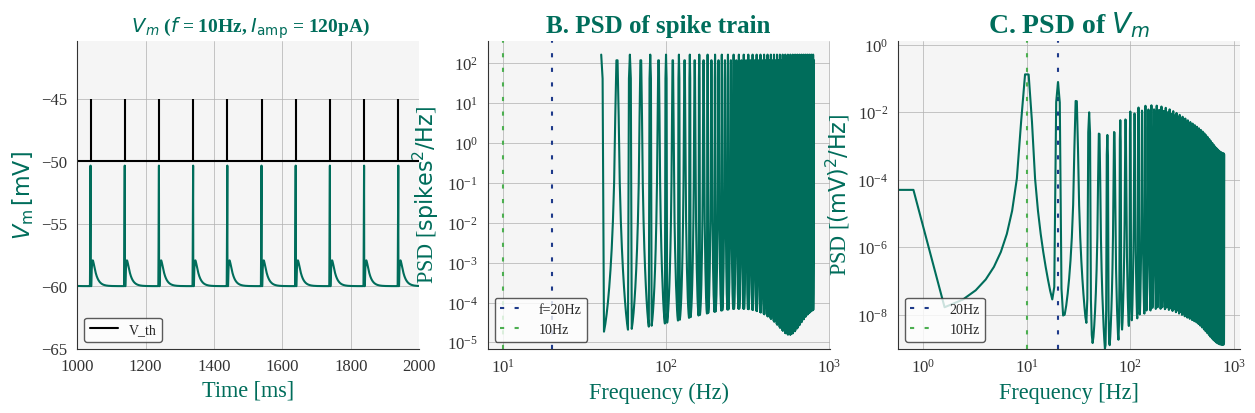

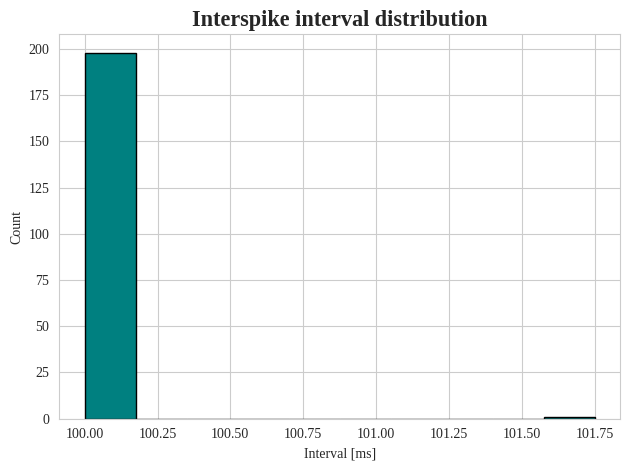

In [11]:
plot_results(sim_time=20e3, tau_syn_ex=2,
             a_values=[120],f_values=[10], delay_sd=0.25, delay_mean=5,
             noisy=False, SD_values=[250],num_A=1000, weight=1,
             bin_size=0.25,xLim=1,second_sine=False, beat=20, harmonics_beat=1,harmonics=1,
             log=True, resolution=0.25, neuron_type="iaf_psc_exp")